In [1]:
import re
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from eval_commons import (load_summary_jsons_fast,
                         create_summary_dataframe,
                         vbs_analysis, plot_winners, parse_solution_file, parse_solution_dir)

In [2]:
def build_strategy(row):
    cols = ["item_assignment_algo", "batching_algo", "routing_algo", "scheduling_algo"]
    parts = [str(row[c]) for c in cols if pd.notna(row[c]) and row[c] != ""]
    return "+".join(parts)

def get_problem(row):
    return instance_problem_map[row["instance_set"]]

In [3]:
base_path = "../output/"
cache_path = "./df_results.pkl"

In [4]:
short_names = {
    "Algorithm": "GIA",
    "ClosestDepotMinDistanceSeedBatching": "SEEDCDMinDist",
    "RawInput": "RawInput",
    "OrderNrFiFo": "OrdNr",
    "OrderNrFifoBatching": "OrdNr",
    "FifoBatching": "FiFo",
    "FiFo": "FiFo",
    "DueDateBatching": "DueDate",
    "ClarkAndWrightSShape": "SavingsSShape",
    "Random": "RAND",
    "RandomBatching": "RAND",
    "ExactSolving": "TSP",
    "RatliffRosenthalRouting": "RR",
    "closest_to_depot_shared_articles_SeedBatching": "SEEDCDMaxArticles",
    "ClosestDepotMaxSharedArticlesSeedBatching": "SEEDCDMaxArticles",
    "closest_to_depot_min_distance_SeedBatching": "SEEDCDMinDist",
    "RatliffRosenthalSavingsBatching": "SavingsRR",
    "NearestNeighbourhoodRouting_SavingsBatching": "SavingsNN",
    "SShapeRouting_SavingsBatching": "SavingsSShape",
    "RatliffRosenthalRouting_SavingsBatching": "SavingsRR",
    "ClarkAndWrightRR": "SavingsRR",
    "ClarkAndWrightNN": "SavingsNN",
    "RatliffRosenthalRouting_OrderNrFiFoBatching_LocalSearchBatching": "LSFiFoRR",
    "RatliffRosenthalRouting_RandomBatching_LocalSearchBatching": "LSRANDRR",
    "NearestNeighbourhoodRouting_RandomBatching_LocalSearchBatching": "LSRANDNN",
    "LSBatchingNNRand": "LSRANDNN",
    "NearestNeighbourhoodRouting_FiFoBatching_LocalSearchBatching": "LSFiFoNN",
    "NearestNeighbourhoodRouting_DueDateBatching_LocalSearchBatching": "LSDueDateNN",
    "LSBatchingNNDueDate": "LSDueDateNN",
    "LSBatchingNNFiFo": "LSFiFoNN",
    "NearestNeighbourhoodRouting_OrderNrFiFoBatching_LocalSearchBatching": "LSOrdNrNN",
    "LSBatchingNNFiFoOrderNr": "LSOrdNrNN",
    # "FIFOOrder": "OrdNr",
    # "OrderNrFiFo": "OrdNr",
    "RawPickListGeneration": "RawInput",
    "SShapeRouting": "SShape",
    "MidpointRouting": "MP",
    "Midpoint": "MP",
    "LargestGapRouting": "LG",
    "LargestGap": "LG",
    "ReturnRouting": "RET",
    "Return": "RET",
    "RatliffRosenthal": "RR",
    "NearestNeighbourhoodRouting": "NN",
    "NearestNeighbourhood": "NN",
    "ExactTSPRoutingDistance": "TSP",
    "MinMinItemAssignment": "MinMinIA",
    "NearestNeighborPickLocationSelector": "NNIA",
    "GreedyPickLocationSelector": "GIA",
    "GreedyItemAssignment": "GIA",
    "LPTScheduling": "LPT",
    "LPTScheduler": "LPT",
    "SPTScheduling": "SPT",
    "SPTScheduler": "SPT",
    "EDDScheduling": "EDD",
    "EDDScheduler": "EDD",
    "GreedyIA": "GIA"
}

instance_problem_map = {
    "SPRP": "SPRP",
    "SPRP-SS": "SPRP",
    "BahceciOencan": "OBRP",
    "HennWaescherUniform": "OBRP",
    "HennWaescherClassBased": "OBRP",
    "HennWaescher": "OBRP",
    "MuterOencan": "OBRP",
    "FoodmartData": "OBRP",
    "IOPVRP": "OBSRP",
    "KrisSmallDataCorrected": "OBSRP",
    "KrisLargeData": "OBSRP",
    "Kris": "OBSRP"
}

In [5]:
# sets_to_load = [
# "SPRP",
# "SPRP-SS",
# "BahceciOencan",
# "HennWaescherUniform",
# "HennWaescherClassBased",
# "MuterOencan",
# "FoodmartData",
# "KrisSmallDataCorrected",
# "KrisLargeData"
# ]  # uncomment this only if you want to load new results, else read the pickled df

sets_to_load = None
df = pd.read_pickle(cache_path)
print(df.groupby(by="instance_set").agg({"instance_name": "count"}))
df_summary = pd.DataFrame()
if sets_to_load:
    summary_data = load_summary_jsons_fast(base_path, sets_to_load)
    print(f"Loaded {len(summary_data)} summary files")
    df_summary = create_summary_dataframe(summary_data)

if not df_summary.empty:
    replace_sets = set(df_summary["instance_set"].unique())
    if not df.empty and "instance_set" in df.columns:
        df = df[~df["instance_set"].isin(replace_sets)]
    df = pd.concat([df, df_summary], ignore_index=True)

df["item_assignment_algo"] = df["item_assignment_algo"].replace(short_names)
df["batching_algo"] = df["batching_algo"].replace(short_names)
df["routing_algo"] = df["routing_algo"].replace(short_names)
df["scheduling_algo"] = df["scheduling_algo"].replace(short_names)
df["strategy"] = df.apply(build_strategy, axis=1)
df["problem_type"] = df.apply(get_problem, axis=1)
df["total_cpu_time"] = df["routing_input_time"] + df["total_route_time"]

# Save updated cache
df.to_pickle(cache_path)
print("\nDataFrame Summary:")
# print(df.head())
print(df.groupby(by="instance_set").agg({"instance_name": "count"}))
# print(f"\nDataFrame Shape: {df.shape}")

                        instance_name
instance_set                         
BahceciOencan                   90450
FoodmartData                     6480
HennWaescher                   380142
KrisLargeData                   61620
KrisSmallDataCorrected          63180
MuterOencan                     17820
SPRP                            14400
SPRP-SS                        429000

DataFrame Summary:
                        instance_name
instance_set                         
BahceciOencan                   90450
FoodmartData                     6480
HennWaescher                   380142
KrisLargeData                   61620
KrisSmallDataCorrected          63180
MuterOencan                     17820
SPRP                            14400
SPRP-SS                        429000


In [6]:
# df = df[df["instance_set"]!="Kris"]

In [7]:
# df.to_pickle(cache_path)

In [8]:
df[(df["instance_set"]=="BahceciOencan")]

,instance_name,instance_set,total_distance,routing_input_time,makespan,on_time_rate,avg_tardiness,max_lateness,max_tardiness,avg_lateness,...,std_batch_distance,min_route_time,max_route_time,avg_route_time,median_route_time,std_route_time,total_route_time,strategy,problem_type,total_cpu_time
847842,Pr_20_1_20_Store1_03,BahceciOencan,201.2,0.000048,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000177,0.000177,0.000177,0.000177,0.000000,0.000177,GIA+RAND+RET,OBRP,0.000226
847843,Pr_20_1_20_Store1_02,BahceciOencan,151.2,0.001811,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000148,0.000148,0.000148,0.000148,0.000000,0.000148,GIA+SavingsNN+SShape,OBRP,0.001958
847844,Pr_20_1_20_Store1_02,BahceciOencan,125.2,0.001386,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000212,0.000212,0.000212,0.000212,0.000000,0.000212,GIA+LSBatchingRR+NN,OBRP,0.001598
847845,Pr_20_1_20_Store1_02,BahceciOencan,119.2,0.000033,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000174,0.000174,0.000174,0.000174,0.000000,0.000174,GIA+OrdNr+LG,OBRP,0.000207
847846,Pr_20_1_20_Store1_01,BahceciOencan,427.6,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,15.127376,0.000023,0.000446,0.000087,0.000036,0.000136,0.000696,GIA+RawInput+LG,OBRP,0.000696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938287,Pr_30_6_05_Store5_30,BahceciOencan,276.8,0.000932,NaN,NaN,NaN,NaN,NaN,NaN,...,7.421291,0.000035,0.000071,0.000044,0.000039,0.000012,0.000262,GIA+SEEDCDMinDist+NN,OBRP,0.001193
938288,Pr_30_6_05_Store5_30,BahceciOencan,312.0,0.000994,NaN,NaN,NaN,NaN,NaN,NaN,...,6.273755,0.000032,0.000078,0.000044,0.000037,0.000015,0.000352,GIA+SavingsSShape+NN,OBRP,0.001346
938289,Pr_30_6_05_Store5_30,BahceciOencan,368.4,0.004411,NaN,NaN,NaN,NaN,NaN,NaN,...,12.009248,0.000030,0.000056,0.000043,0.000047,0.000009,0.000303,GIA+LSRANDNN+SShape,OBRP,0.004714
938290,Pr_30_6_05_Store5_30,BahceciOencan,444.8,0.052977,NaN,NaN,NaN,NaN,NaN,NaN,...,6.723756,0.000045,0.000056,0.000051,0.000053,0.000004,0.000306,GIA+SavingsRR+RET,OBRP,0.053283


In [9]:
df["routing_algo"].unique()

array(['LG', 'NN', 'MP', 'RR', 'RET', 'SShape',
       'CombinedBatchingRoutingAssigning'], dtype=object)

In [10]:
df.loc[df["instance_set"] == "HennWaescherClassBased", "instance_name"] = (
    df.loc[df["instance_set"] == "HennWaescherClassBased", "instance_name"] + "_cb"
)

In [11]:
df.loc[df["instance_set"] == "HennWaescherUniform", "instance_name"] = (
    df.loc[df["instance_set"] == "HennWaescherUniform", "instance_name"] + "_u"
)

In [12]:
df.loc[df["instance_set"] == "HennWaescherUniform", "instance_set"] = "HennWaescher"
df.loc[df["instance_set"] == "HennWaescherClassBased", "instance_set"] = "HennWaescher"

In [13]:
df.loc[df["instance_set"] == "KrisSmallDataCorrected", "instance_name"] = (
    df.loc[df["instance_set"] == "KrisSmallDataCorrected", "instance_name"] + "_small"
)

In [14]:
df.loc[df["instance_set"] == "KrisLargeData", "instance_name"] = (
    df.loc[df["instance_set"] == "KrisLargeData", "instance_name"] + "_large"
)

In [15]:
df.loc[df["instance_set"] == "KrisSmallDataCorrected", "instance_set"] = "Kris"
df.loc[df["instance_set"] == "KrisLargeData", "instance_set"] = "Kris"

# Pipeline Overview

In [16]:
df["routing_algo"].unique()

array(['LG', 'NN', 'MP', 'RR', 'RET', 'SShape',
       'CombinedBatchingRoutingAssigning'], dtype=object)

In [17]:
df["batching_algo"].unique()

array(['RawInput', 'SavingsSShape', 'LSRANDNN', 'SavingsNN', 'LSOrdNrNN',
       'SEEDCDMinDist', 'SEEDCDMaxArticles', 'RAND', 'OrdNr',
       'LSBatchingRR', 'SavingsRR', None, 'LSFiFoNN', 'LSDueDateNN',
       'DueDate', 'FiFo'], dtype=object)

In [18]:
pipeline_results_overview = df.groupby("instance_set").agg(
    n_item_assignment_algos=("item_assignment_algo", "nunique"),
    n_routing_algos=("routing_algo", "nunique"),
    n_pick_list_gen_algos=("batching_algo", "nunique"),
    n_combined_br_algos=("batching_algo", lambda x: 0),  # placeholder
    n_scheduling_algos=("scheduling_algo", "nunique"),
    n_instances=("instance_name", "nunique"),
    n_pipelines=("total_distance", "count")
)

# Manually set BR count for BahceciOencan
pipeline_results_overview.loc["BahceciOencan", "n_combined_br_algos"] = 1
pipeline_results_overview.loc["BahceciOencan", "n_routing_algos"] -= 1


In [19]:
pipeline_results_overview_tex = pipeline_results_overview.to_latex(index=True, caption="Pipeline results overview", label="tab:pipeline_results", escape=True)

In [20]:
pipeline_results_overview

,n_item_assignment_algos,n_routing_algos,n_pick_list_gen_algos,n_combined_br_algos,n_scheduling_algos,n_instances,n_pipelines
instance_set,,,,,,,
BahceciOencan,1,6,11,1,0,1350,90450
FoodmartData,1,5,9,0,0,144,6480
HennWaescher,1,6,11,0,0,5760,380142
Kris,1,5,13,0,3,480,124800
MuterOencan,1,6,11,0,0,270,17820
SPRP,0,6,1,0,0,2400,14400
SPRP-SS,5,6,1,0,0,14300,429000


In [21]:
df[df["instance_set"]=="Kris"]["batching_algo"].unique()

array(['RAND', 'SavingsSShape', 'SEEDCDMinDist', 'OrdNr',
       'SEEDCDMaxArticles', 'LSFiFoNN', 'LSDueDateNN', 'RawInput',
       'LSOrdNrNN', 'DueDate', 'FiFo', 'SavingsNN', 'LSRANDNN'],
      dtype=object)

In [22]:
df[df["instance_set"]=="HennWaescher"]["batching_algo"].unique()

array(['LSBatchingRR', 'SavingsNN', 'SavingsSShape', 'RawInput',
       'SavingsRR', 'SEEDCDMaxArticles', 'LSOrdNrNN', 'OrdNr', 'RAND',
       'SEEDCDMinDist', 'LSRANDNN'], dtype=object)

In [23]:
df[df["instance_set"]=="MuterOencan"]["batching_algo"].unique()

array(['RawInput', 'SavingsRR', 'SavingsNN', 'LSRANDNN',
       'SEEDCDMaxArticles', 'SEEDCDMinDist', 'LSBatchingRR', 'RAND',
       'OrdNr', 'SavingsSShape', 'LSOrdNrNN'], dtype=object)

In [24]:
df[df["instance_set"]=="BahceciOencan"]["batching_algo"].unique()

array(['RAND', 'SavingsNN', 'LSBatchingRR', 'OrdNr', 'RawInput',
       'SavingsRR', 'LSRANDNN', 'SEEDCDMinDist', 'LSOrdNrNN',
       'SavingsSShape', 'SEEDCDMaxArticles', None], dtype=object)

In [25]:
df[df["instance_set"]=="FoodmartData"]["batching_algo"].unique()

array(['SavingsSShape', 'LSRANDNN', 'SavingsNN', 'LSOrdNrNN',
       'SEEDCDMinDist', 'SEEDCDMaxArticles', 'RAND', 'RawInput', 'OrdNr'],
      dtype=object)

In [26]:
df[df["instance_set"]=="HennWaescher"]["routing_algo"].unique()

array(['RET', 'RR', 'NN', 'SShape', 'LG', 'MP'], dtype=object)

In [27]:
df[df["instance_set"]=="BahceciOencan"]["batching_algo"].unique()

array(['RAND', 'SavingsNN', 'LSBatchingRR', 'OrdNr', 'RawInput',
       'SavingsRR', 'LSRANDNN', 'SEEDCDMinDist', 'LSOrdNrNN',
       'SavingsSShape', 'SEEDCDMaxArticles', None], dtype=object)

In [28]:
df[df["instance_set"]=="MuterOencan"]["batching_algo"].unique()

array(['RawInput', 'SavingsRR', 'SavingsNN', 'LSRANDNN',
       'SEEDCDMaxArticles', 'SEEDCDMinDist', 'LSBatchingRR', 'RAND',
       'OrdNr', 'SavingsSShape', 'LSOrdNrNN'], dtype=object)

In [29]:
df[df["instance_set"]=="MuterOencan"]["strategy"].nunique()

66

In [30]:
df[df["instance_set"]=="MuterOencan"]["routing_algo"].unique()


array(['LG', 'NN', 'RR', 'SShape', 'MP', 'RET'], dtype=object)

In [31]:
df[(df["instance_set"]=="Kris")].groupby(by=["instance_name"]).count()

,instance_set,total_distance,routing_input_time,makespan,on_time_rate,avg_tardiness,max_lateness,max_tardiness,avg_lateness,item_assignment_algo,...,std_batch_distance,min_route_time,max_route_time,avg_route_time,median_route_time,std_route_time,total_route_time,strategy,problem_type,total_cpu_time
instance_name,,,,,,,,,,,,,,,,,,,,,
instances_100_1_large,260,260,260,195,195,195,195,195,195,260,...,260,260,260,260,260,260,260,260,260,260
instances_100_1_small,260,260,260,195,195,195,195,195,195,260,...,260,260,260,260,260,260,260,260,260,260
instances_101_1_large,260,260,260,195,195,195,195,195,195,260,...,260,260,260,260,260,260,260,260,260,260
instances_101_1_small,260,260,260,195,195,195,195,195,195,260,...,260,260,260,260,260,260,260,260,260,260
instances_102_1_large,260,260,260,195,195,195,195,195,195,260,...,260,260,260,260,260,260,260,260,260,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
instances_98_1_small,260,260,260,195,195,195,195,195,195,260,...,260,260,260,260,260,260,260,260,260,260
instances_99_1_large,260,260,260,195,195,195,195,195,195,260,...,260,260,260,260,260,260,260,260,260,260
instances_99_1_small,260,260,260,195,195,195,195,195,195,260,...,260,260,260,260,260,260,260,260,260,260


In [32]:
print(pipeline_results_overview_tex)

\begin{table}
\caption{Pipeline results overview}
\label{tab:pipeline_results}
\begin{tabular}{lrrrrrrr}
\toprule
 & n\_item\_assignment\_algos & n\_routing\_algos & n\_pick\_list\_gen\_algos & n\_combined\_br\_algos & n\_scheduling\_algos & n\_instances & n\_pipelines \\
instance_set &  &  &  &  &  &  &  \\
\midrule
BahceciOencan & 1 & 6 & 11 & 1 & 0 & 1350 & 90450 \\
FoodmartData & 1 & 5 & 9 & 0 & 0 & 144 & 6480 \\
HennWaescher & 1 & 6 & 11 & 0 & 0 & 5760 & 380142 \\
Kris & 1 & 5 & 13 & 0 & 3 & 480 & 124800 \\
MuterOencan & 1 & 6 & 11 & 0 & 0 & 270 & 17820 \\
SPRP & 0 & 6 & 1 & 0 & 0 & 2400 & 14400 \\
SPRP-SS & 5 & 6 & 1 & 0 & 0 & 14300 & 429000 \\
\bottomrule
\end{tabular}
\end{table}



In [33]:
instance_names_sorted = ["SPRP", "SPRP-SS", "BahceciOencan", "HennWaescher", "MuterOencan", "FoodmartData", "Kris"]
pro = pipeline_results_overview.reindex(instance_names_sorted)

# Italicize instance names
pro.index = [r"\textit{" + name + "}" for name in pro.index]

# Rename columns to short labels
pro.columns = ["IA", "R", "B", "BR", "S", r"\# instances", r"\# pipelines"]

# Build data rows
rows = []
for idx, row in pro.iterrows():
    vals = " & ".join(str(int(v)) if pd.notna(v) else "--" for v in row)
    rows.append(rf"{idx} & {vals} \\")

body = "\n".join(rows)

# Sum row
col_instances = r"\# instances"
col_pipelines = r"\# pipelines"
sum_instances = int(pro[col_instances].sum())
sum_pipelines = int(pro[col_pipelines].sum())
total_instances = f"{sum_instances:,}"
total_pipelines = f"{sum_pipelines:,}"

latex = rf"""
\begin{{table}}
\caption{{Number of resulting pipelines per instance set.}}
\label{{tab:pipeline_results}}
\begin{{tabular}}{{lrrrrrrr}}
\toprule
  & \multicolumn{{5}}{{c}}{{\# algorithms}} & \# instances & \# pipelines\\
\cmidrule(lr){{2-6}}
instance set & IA & R & B & BR & S &  &  \\
\midrule
{body}
\bottomrule
$\sum$ &  &  &  &  &  & {total_instances} & {total_pipelines}\\
\end{{tabular}}
\end{{table}}
"""

print(latex)


\begin{table}
\caption{Number of resulting pipelines per instance set.}
\label{tab:pipeline_results}
\begin{tabular}{lrrrrrrr}
\toprule
  & \multicolumn{5}{c}{\# algorithms} & \# instances & \# pipelines\\
\cmidrule(lr){2-6}
instance set & IA & R & B & BR & S &  &  \\
\midrule
\textit{SPRP} & 0 & 6 & 1 & 0 & 0 & 2400 & 14400 \\
\textit{SPRP-SS} & 5 & 6 & 1 & 0 & 0 & 14300 & 429000 \\
\textit{BahceciOencan} & 1 & 6 & 11 & 1 & 0 & 1350 & 90450 \\
\textit{HennWaescher} & 1 & 6 & 11 & 0 & 0 & 5760 & 380142 \\
\textit{MuterOencan} & 1 & 6 & 11 & 0 & 0 & 270 & 17820 \\
\textit{FoodmartData} & 1 & 5 & 9 & 0 & 0 & 144 & 6480 \\
\textit{Kris} & 1 & 5 & 13 & 0 & 3 & 480 & 124800 \\
\bottomrule
$\sum$ &  &  &  &  &  & 24,704 & 1,063,092\\
\end{tabular}
\end{table}



# VBS per Instance Set

In [34]:
df_vbs_overview = pd.DataFrame()
df_all_winners = []  # collect winners across instance sets

for instance in df["instance_set"].unique():
    df_instance = df[df["instance_set"] == instance]
    df_instance = df_instance[(df_instance["total_distance"]!= 0) & (df_instance["scheduling_algo"].isna())]
    result, winner_counts = vbs_analysis(df_instance)
    result["problem_type"] = df_instance["problem_type"].unique()
    df_winners = winner_counts.reset_index()
    df_winners.columns = ["strategy", "count"]
    df_winners["relative_%"] = df_winners["count"] / df_winners["count"].sum() * 100
    df_winners["instance_set"] = instance
    # df_winners["problem"] = df_instance["problem_type"]

    df_all_winners.append(df_winners)  # store for later

    df_vbs_overview = pd.concat([df_vbs_overview, result], ignore_index=True)

df_vbs_overview["objective"] = "distance"
# Combine all winners into a single dataframe
df_all_winners = pd.concat(df_all_winners, ignore_index=True)

In [35]:
df_instance_kris = df[df["instance_set"]=="Kris"]
df_instance_kris_dd = df_instance_kris[(df_instance_kris["on_time_rate"]!="") & df_instance_kris["scheduling_algo"]]

result_makespan, _ = vbs_analysis(df_instance_kris_dd, metric_col="makespan")
result_makespan["objective"] = "makespan"
result_makespan["problem_type"] = df_instance_kris_dd["problem_type"].unique()

result_max_tard, _ = vbs_analysis(df_instance_kris_dd, metric_col="max_tardiness")
result_max_tard["objective"] = "max_tardiness"
result_max_tard["problem_type"] = df_instance_kris_dd["problem_type"].unique()

result_avg_tard, _ = vbs_analysis(df_instance_kris_dd, metric_col="avg_tardiness")
result_avg_tard["objective"] = "avg_tardiness"
result_avg_tard["problem_type"] = df_instance_kris_dd["problem_type"].unique()

result_max_late, _ = vbs_analysis(df_instance_kris_dd, metric_col="max_lateness")
result_max_late["objective"] = "max_lateness"
result_max_late["problem_type"] = df_instance_kris_dd["problem_type"].unique()

result_on_time, _ = vbs_analysis(df_instance_kris_dd, metric_col="on_time_rate", min_max="max")
result_on_time["objective"] = "on_time_rate"
result_on_time["problem_type"] = df_instance_kris_dd["problem_type"].unique()

In [36]:
result_max_late

,instance_set,SBS Strategy,SBS Mean,VBS Mean,Relative Gain %,objective,problem_type
0,Kris,GIA+DueDate+NN+EDD,-13790.458333,-14936.95,-8.313659,max_lateness,OBSRP


In [37]:
result_on_time

,instance_set,SBS Strategy,SBS Mean,VBS Mean,Relative Gain %,objective,problem_type
0,Kris,GIA+DueDate+NN+EDD,96.492014,97.941667,1.502355,on_time_rate,OBSRP


In [38]:
df_vbs_overview = pd.concat([df_vbs_overview, result_makespan, result_max_tard, result_on_time], ignore_index=True)

In [39]:
instance_names_sorted = ["SPRP", "SPRP-SS", "BahceciOencan", "HennWaescher", "MuterOencan", "FoodmartData", "Kris"]
df_vbs_overview_tex = df_vbs_overview.round(2)
df_vbs_overview_tex['instance_set'] = pd.Categorical(
    df_vbs_overview_tex['instance_set'], categories=instance_names_sorted, ordered=True)
df_vbs_overview_tex = df_vbs_overview_tex.sort_values('instance_set')
# Build column alignment: left for first col, right for the rest
colfmt = "l" + "r" * (df_vbs_overview_tex.shape[1] - 1)

df_vbs_overview_tex['instance_set'] = df_vbs_overview_tex['instance_set'].apply(
    lambda x: rf"\textit{{{x}}}")

df_vbs_overview_tex = df_vbs_overview_tex.rename(columns={
    'instance_set': 'Instance Set',
    'problem_type': 'Problem Type',
})
# Generate LaTeX tabular
latex_tabular = df_vbs_overview_tex.to_latex(
    index=False,
    escape=False,                # escape underscores, % etc.
    na_rep="--",
    column_format=colfmt,
    float_format="%.2f"
)

# Wrap with adjustbox for page fit
df_vbs_overview_tex = rf"""
\begin{{table}}[!htbp]
\centering
\caption{{VBS overview}}
\label{{tab:vbs_overview}}
\begin{{adjustbox}}{{width=\linewidth,center}}
{latex_tabular}
\end{{adjustbox}}
\end{{table}}
"""

print(df_vbs_overview_tex)


\begin{table}[!htbp]
\centering
\caption{VBS overview}
\label{tab:vbs_overview}
\begin{adjustbox}{width=\linewidth,center}
\begin{tabular}{lrrrrrr}
\toprule
Instance Set & SBS Strategy & SBS Mean & VBS Mean & Relative Gain % & Problem Type & objective \\
\midrule
\textit{SPRP} & RawInput+RR & 589.83 & 589.83 & 0.00 & SPRP & distance \\
\textit{SPRP-SS} & MinMinIA+RawInput+RR & 395.28 & 385.78 & 2.40 & SPRP & distance \\
\textit{BahceciOencan} & GIA+CombinedBatchingRoutingAssigning & 168.28 & 168.10 & 0.11 & OBRP & distance \\
\textit{HennWaescher} & GIA+SavingsRR+RR & 8114.34 & 8083.06 & 0.39 & OBRP & distance \\
\textit{MuterOencan} & GIA+SavingsRR+RR & 1322.84 & 1308.77 & 1.06 & OBRP & distance \\
\textit{FoodmartData} & GIA+SavingsSShape+SShape & 2308.86 & 2095.33 & 9.25 & OBRP & distance \\
\textit{Kris} & GIA+SavingsNN+NN & 144075.76 & 143695.02 & 0.26 & OBSRP & distance \\
\textit{Kris} & GIA+SavingsNN+NN+LPT & 71367.04 & 70038.94 & 1.86 & OBSRP & makespan \\
\textit{Kris} & GIA

## Foodmart Deep Dive

In [40]:
winning_str_fm = df_all_winners[df_all_winners["instance_set"]=="FoodmartData"].strategy.unique()

In [41]:
winning_str_fm

array(['GIA+LSOrdNrNN+NN', 'GIA+LSRANDNN+NN', 'GIA+SEEDCDMaxArticles+NN',
       'GIA+SavingsSShape+SShape', 'GIA+SavingsNN+NN',
       'GIA+SEEDCDMaxArticles+SShape'], dtype=object)

In [42]:
df_fm = df[df["instance_set"]=="FoodmartData"]
df_fm["instance_name"] = df_fm["instance_name"].str.replace(r'^instances_|_MAL$', '', regex=True)

C:\Users\zm0714\AppData\Local\Temp\ipykernel_40396\938642340.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fm["instance_name"] = df_fm["instance_name"].str.replace(r'^instances_|_MAL$', '', regex=True)


In [43]:
df_fm["n_orders"] = df_fm["instance_name"].str.extract(r"ord(\d+)").astype(int)

C:\Users\zm0714\AppData\Local\Temp\ipykernel_40396\4210362195.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fm["n_orders"] = df_fm["instance_name"].str.extract(r"ord(\d+)").astype(int)


In [44]:
df_fm_vbs = df_fm.loc[df_fm.groupby("instance_name")["total_distance"].idxmin(), ["instance_set", "instance_name", "strategy", "total_distance", "total_cpu_time"]]

In [45]:
def create_pipelines_summary(df_instance: pd.DataFrame):
    pipeline_summary = df_instance.groupby('strategy').agg({
        # 'gap_[%]': 'mean',
        'total_cpu_time': 'mean',
        'total_distance': 'mean',
        'instance_set': 'count'
    }).reset_index()
    
    pipeline_summary.columns = ['strategy', 'mean runtime', 'mean distance', 'n instances']
    pipeline_summary.sort_values(by="mean distance", inplace=True)
    
    return pipeline_summary

In [46]:
# row_vbs_fm = create_row_vbs(df_fm_vbs)

pipeline_summary_fm = create_pipelines_summary(df_fm)

pipeline_summary_fm = pd.concat([pipeline_summary_fm], ignore_index=True)
display(pipeline_summary_fm)

,strategy,mean runtime,mean distance,n instances
0,GIA+SavingsSShape+SShape,1.283254,2308.864375,144
1,GIA+SavingsNN+NN,2.366949,2328.227222,144
2,GIA+SavingsSShape+NN,1.283147,2362.365347,144
3,GIA+LSOrdNrNN+NN,8.108028,2372.383125,144
4,GIA+LSRANDNN+NN,8.306967,2456.410556,144
5,GIA+SEEDCDMinDist+NN,0.113085,2658.899583,144
6,GIA+SavingsNN+SShape,2.366284,2753.584653,144
7,GIA+OrdNr+NN,0.005143,2754.447917,144
8,GIA+SavingsSShape+LG,1.284455,2758.967569,144
9,GIA+SEEDCDMaxArticles+NN,0.033977,2781.964306,144


In [47]:
ultra_large_fm = ["ord1000_fsd10", "ord2000_fsd10", "ord500_fsd10"]

In [48]:
result, winner_counts = vbs_analysis(df_fm[~df_fm["instance_name"].isin(ultra_large_fm)])

In [49]:
result

,instance_set,SBS Strategy,SBS Mean,VBS Mean,Relative Gain %
0,FoodmartData,GIA+LSOrdNrNN+NN,1518.714965,1506.772837,0.786331


In [50]:
# # mean distance per strategy per n_orders
df_fm_winners = df_fm[(df_fm["strategy"].isin(winning_str_fm))]
# perf = df_fm_winners.groupby(["n_orders", "strategy"])["total_distance"].mean().reset_index()

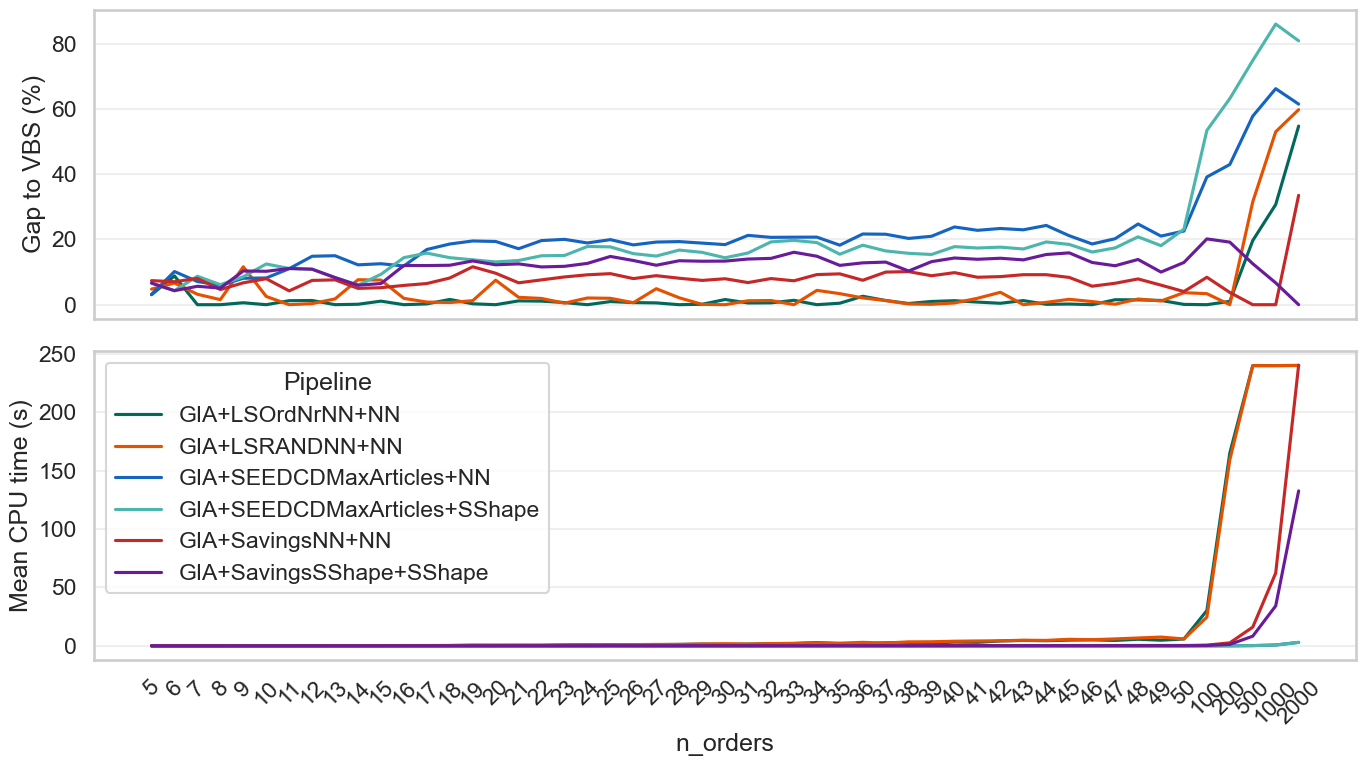

In [51]:
# compute mean distance and mean runtime per strategy per n_orders
perf = df_fm_winners.groupby(["n_orders", "strategy"])[["total_distance", "total_cpu_time"]].mean().reset_index()

# compute VBS per n_orders
vbs = df_fm_winners.groupby(["n_orders", "instance_name"])["total_distance"].min()
vbs_mean = vbs.groupby("n_orders").mean().rename("vbs")

perf = perf.merge(vbs_mean, on="n_orders")
perf["gap_pct"] = (perf["total_distance"] - perf["vbs"]) / perf["vbs"] * 100

perf["n_orders"] = perf["n_orders"].astype(str)
order = sorted(perf["n_orders"].unique(), key=lambda x: int(x))

rank_palette = [
    "#00695C", "#E65100", "#1565C0", "#4DB6AC", "#C62828",
    "#6A1B9A", "#80CBC4", "#F9A825", "#00897B", "#AD1457",
    "#2E7D32", "#5C6BC0", "#EF6C00", "#00838F", "#4E342E",
    "#78909C", "#26A69A", "#D81B60", "#558B2F", "#3949AB",
]

sns.set_style("whitegrid", {'axes.grid' : False})
sns.set_context("talk")

strategies = perf["strategy"].unique()
palette = rank_palette[:len(strategies)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor('none')
for ax in axes:
    ax.grid(axis='y', alpha=0.3)
sns.lineplot(x="n_orders", y="gap_pct", hue="strategy", data=perf, ax=axes[0], sort=False, palette=palette)
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order)
axes[0].set_ylabel("Gap to VBS (%)")

sns.lineplot(x="n_orders", y="total_cpu_time", hue="strategy", data=perf, ax=axes[1], sort=False, palette=palette)
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order, rotation=45)
axes[1].set_ylabel("Mean CPU time (s)")


axes[1].legend(title="Pipeline")
axes[0].get_legend().remove()
    
plt.tight_layout()
plt.savefig('./plots/foodmart_strategy_vs_vbs_distance_time.png', dpi=200, bbox_inches='tight', pad_inches=0)


In [185]:
df[df["instance_name"]=="10l-40-45-5_u"]

,instance_name,instance_set,total_distance,routing_input_time,makespan,on_time_rate,avg_tardiness,max_lateness,max_tardiness,avg_lateness,...,std_batch_distance,min_route_time,max_route_time,avg_route_time,median_route_time,std_route_time,total_route_time,strategy,problem_type,total_cpu_time
452190,10l-40-45-5_u,HennWaescher,7355.0,0.119172,NaN,NaN,NaN,NaN,NaN,NaN,...,61.173340,0.000242,0.000567,0.000456,0.000475,0.000080,0.005924,GIA+SEEDCDMinDist+LG,OBRP,0.125096
452191,10l-40-45-5_u,HennWaescher,6406.0,1.260774,NaN,NaN,NaN,NaN,NaN,NaN,...,41.742930,0.000432,0.000676,0.000530,0.000511,0.000062,0.006361,GIA+SavingsRR+NN,OBRP,1.267135
452192,10l-40-45-5_u,HennWaescher,7621.0,2.912663,NaN,NaN,NaN,NaN,NaN,NaN,...,120.570434,0.000115,0.000563,0.000410,0.000445,0.000118,0.005740,GIA+LSBatchingRR+MP,OBRP,2.918403
452193,10l-40-45-5_u,HennWaescher,17352.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,97.565926,0.000104,0.001039,0.000256,0.000238,0.000148,0.010244,GIA+RawInput+SShape,OBRP,0.010244
452194,10l-40-45-5_u,HennWaescher,13525.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,77.466828,0.000878,0.001846,0.001183,0.001117,0.000245,0.047339,GIA+RawInput+RR,OBRP,0.047339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452251,10l-40-45-5_u,HennWaescher,9928.0,0.016666,NaN,NaN,NaN,NaN,NaN,NaN,...,136.280471,0.000145,0.000702,0.000489,0.000481,0.000125,0.006363,GIA+SEEDCDMaxArticles+RET,OBRP,0.023029
452252,10l-40-45-5_u,HennWaescher,14946.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,83.451049,0.000097,0.000498,0.000254,0.000239,0.000086,0.010156,GIA+RawInput+MP,OBRP,0.010156
452253,10l-40-45-5_u,HennWaescher,9343.0,1.260774,NaN,NaN,NaN,NaN,NaN,NaN,...,67.979725,0.000421,0.000814,0.000539,0.000528,0.000095,0.006463,GIA+SavingsRR+RET,OBRP,1.267238
452254,10l-40-45-5_u,HennWaescher,10349.0,0.119172,NaN,NaN,NaN,NaN,NaN,NaN,...,96.621754,0.000294,0.000662,0.000509,0.000503,0.000086,0.006622,GIA+SEEDCDMinDist+RET,OBRP,0.125794


# Load and Preprocess Datasets and Results

In [52]:
# \textit{FoodmartData} & GIA+SavingsNN+NN & 2299.58 & 2095.33 & 8.88 & OBRP & distance \\


## SPRP

In [53]:
instance_set_sprp = "SPRP"
results_sprp = pd.read_csv(f"../../data/results/results_{instance_set_sprp}.csv", sep=";", decimal=",",      # Comma is decimal separator
    thousands=".")

In [54]:
results_sprp["filename"] = results_sprp.apply(
    lambda
        row: f"unit_F1_m{row['num aisles']}_C{row['num cells']}_a{row['num articles']}_{row['random seed']}",
    axis=1
)
results_sprp.rename(columns={"GS MIP cost": "best_literature"}, inplace=True)

In [55]:
df_sprp = df[df["instance_set"]==instance_set_sprp]
df_sprp = df_sprp.merge(right=results_sprp, how="left", left_on="instance_name", right_on="filename")
df_sprp["gap_[%]"] = ((df_sprp["total_distance"] - df_sprp["best_literature"]) / df_sprp["best_literature"]) * 100

## SPRP-SS

In [56]:
instance_set_sprp_ss = "SPRP-SS"
results_sprp_ss = pd.read_csv(f"../../data/results/results_{instance_set_sprp_ss}.csv", sep=";", decimal=",",      # Comma is decimal separator
    thousands=".")

In [57]:
results_sprp_ss["demand_helper"] = results_sprp_ss.apply(lambda row: "unit" if row["unit demand"] else "varying", axis=1)
results_sprp_ss["filename"] = results_sprp_ss.apply(
    lambda
        row: f"{row['demand_helper']}_F{row['alpha']}_m{row['num aisles']}_C{row['num cells']}_a{row['num articles']}_{row['random seed']}",
    axis=1
)
results_sprp_ss.rename(columns={"GS MIP cost": "best_literature"}, inplace=True)
# if "LB" in results.columns:
# results["LB"] = results["LB"].astype(str).str.replace(".", ",").astype(float)

In [58]:
df_sprp_ss = df[df["instance_set"]==instance_set_sprp_ss]
df_sprp_ss = df_sprp_ss.merge(right=results_sprp_ss, how="left", left_on="instance_name", right_on="filename")
df_sprp_ss["gap_[%]"] = ((df_sprp_ss["total_distance"] - df_sprp_ss["best_literature"]) / df_sprp_ss["best_literature"]) * 100

## Foodmart

In [59]:
instance_set_fm = "FoodmartData"
results_fm = pd.read_csv(f"../../data/results/results_Foodmart.csv", sep=";", decimal=",",      # Comma is decimal separator
    thousands=".")

In [60]:
results_fm["LB"] = results_fm["LB"].astype(float)
results_fm["UB"] = results_fm["UB"].astype(float)
results_fm["UB after MIP (before post-optimization)"] = results_fm["UB after MIP (before post-optimization)"].astype(float)
results_fm.rename(columns={"UB after MIP (before post-optimization)": "best_literature"}, inplace=True)

In [61]:
df_foodmart = df[df["instance_set"]==instance_set_fm]
df_foodmart["instance_name"] = df_foodmart["instance_name"].str.replace(r'^instances_|_MAL$', '', regex=True)
# df_foodmart = df_foodmart[~df_foodmart["instance_name"].isin(["ord2000_fsd10"])] # , "ord1000_fsd10", "ord500_fsd10", "ord200_fsd10"
# comment out if not benchmarking against results
df_foodmart = df_foodmart.merge(right=results_fm, how="inner", left_on="instance_name", right_on="Name")
df_foodmart["gap_[%]"] = ((df_foodmart["total_distance"] - df_foodmart["best_literature"]) / df_foodmart["best_literature"]) * 100

C:\Users\zm0714\AppData\Local\Temp\ipykernel_40396\1254137850.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_foodmart["instance_name"] = df_foodmart["instance_name"].str.replace(r'^instances_|_MAL$', '', regex=True)


In [62]:
df_foodmart

,instance_name,instance_set,total_distance,routing_input_time,makespan,on_time_rate,avg_tardiness,max_lateness,max_tardiness,avg_lateness,...,CPU Slave (s),CPU Rich Column Set (s),CPU Final MIP (s),CPU Dynamic programming (s),CPU Post-optimization (s),Number of Iterations,Number of initial columns,Number of columns,Number of tours in the best solution found,gap_[%]
0,d10_ord10,FoodmartData,769.18,0.008687,NaN,NaN,NaN,NaN,NaN,NaN,...,6.15,0.16,0.0,13.57,0.0,13,55,319,2,16.225446
1,d10_ord10,FoodmartData,1159.18,0.097233,NaN,NaN,NaN,NaN,NaN,NaN,...,6.15,0.16,0.0,13.57,0.0,13,55,319,2,75.155636
2,d10_ord10,FoodmartData,986.00,0.021126,NaN,NaN,NaN,NaN,NaN,NaN,...,6.15,0.16,0.0,13.57,0.0,13,55,319,2,48.987610
3,d10_ord10,FoodmartData,713.80,0.078057,NaN,NaN,NaN,NaN,NaN,NaN,...,6.15,0.16,0.0,13.57,0.0,13,55,319,2,7.857359
4,d10_ord10,FoodmartData,942.00,0.006607,NaN,NaN,NaN,NaN,NaN,NaN,...,6.15,0.16,0.0,13.57,0.0,13,55,319,2,42.339075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,d5_ord9,FoodmartData,2077.08,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,3.59,0.02,0.0,3.61,0.0,2,45,351,2,284.922444
1886,d5_ord9,FoodmartData,931.19,0.000857,NaN,NaN,NaN,NaN,NaN,NaN,...,3.59,0.02,0.0,3.61,0.0,2,45,351,2,72.567224
1887,d5_ord9,FoodmartData,931.19,0.000042,NaN,NaN,NaN,NaN,NaN,NaN,...,3.59,0.02,0.0,3.61,0.0,2,45,351,2,72.567224
1888,d5_ord9,FoodmartData,699.30,0.004746,NaN,NaN,NaN,NaN,NaN,NaN,...,3.59,0.02,0.0,3.61,0.0,2,45,351,2,29.593595


## HennWaescher

In [63]:
instance_set_hw = "HennWaescher"

## HennWaescherUniform

In [64]:
instance_set_hw_uf = "HennWaescherUniform"

In [65]:
results_hw = pd.read_csv(f"../../data/results/results_HennWaescher.csv", sep=";", decimal=",",      # Comma is decimal separator
    thousands=".")

In [66]:
results_hw['storage_policy'] = results_hw['filename'].str.split('\\').str[0].str.split('_').str[1]
results_hw['filename'] = results_hw['filename'].str.split('\\').str[-1].str.replace('.txt', '', regex=False)

In [67]:
results_hw.loc[results_hw["storage_policy"] == "uniform", "filename"] = (
    results_hw.loc[results_hw["storage_policy"] == "uniform", "filename"] + "_u"
)

results_hw.loc[results_hw["storage_policy"] == "class-based", "filename"] = (
    results_hw.loc[results_hw["storage_policy"] == "class-based", "filename"] + "_cb"
)

In [68]:
# results_hw_uf = results_hw[(results_hw["policy"]=="optimal") & (results_hw["opt?"] == True) & (results_hw["storage_policy"] == "uniform")]
results_hw = results_hw[(results_hw["policy"]=="optimal") & (results_hw["opt?"] == True)]

In [69]:
# df_henn = df[df["instance_set"]==instance_set_hw_uf]
df_henn = df[df["instance_set"]==instance_set_hw]

In [70]:
# df_henn = df_henn.merge(right=results_hw_uf, how="left", left_on="instance_name", right_on="filename")
df_henn = df_henn.merge(right=results_hw, how="left", left_on="instance_name", right_on="filename")
df_henn.rename(columns={"LB": "best_literature"}, inplace=True)

In [71]:
df_henn = df_henn.dropna(subset=["best_literature"])

In [72]:
df_henn["gap_[%]"] = ((df_henn["total_distance"] - df_henn["best_literature"]) / df_henn["best_literature"]) * 100

In [73]:
df_henn

,instance_name,instance_set,total_distance,routing_input_time,makespan,on_time_rate,avg_tardiness,max_lateness,max_tardiness,avg_lateness,...,number of orders,capacity,random seed,policy,opt?,UB,best_literature,time [s],storage_policy,gap_[%]
7914,13l-50-30-0_u,HennWaescher,17057.0,0.704765,NaN,NaN,NaN,NaN,NaN,NaN,...,50.0,30.0,0.0,optimal,True,12688.0,12688.0,478.503,uniform,34.434111
7915,13l-50-30-0_u,HennWaescher,14189.0,0.772569,NaN,NaN,NaN,NaN,NaN,NaN,...,50.0,30.0,0.0,optimal,True,12688.0,12688.0,478.503,uniform,11.830076
7918,13l-50-30-0_u,HennWaescher,16291.0,0.704765,NaN,NaN,NaN,NaN,NaN,NaN,...,50.0,30.0,0.0,optimal,True,12688.0,12688.0,478.503,uniform,28.396910
7919,13l-50-30-0_u,HennWaescher,15045.0,0.000347,NaN,NaN,NaN,NaN,NaN,NaN,...,50.0,30.0,0.0,optimal,True,12688.0,12688.0,478.503,uniform,18.576608
7920,13l-50-30-0_u,HennWaescher,15976.0,0.031013,NaN,NaN,NaN,NaN,NaN,NaN,...,50.0,30.0,0.0,optimal,True,12688.0,12688.0,478.503,uniform,25.914250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380137,9l-40-30-9_cb,HennWaescher,10321.0,0.014815,NaN,NaN,NaN,NaN,NaN,NaN,...,40.0,30.0,9.0,optimal,True,6126.0,6126.0,3600.000,class-based,68.478616
380138,9l-40-30-9_cb,HennWaescher,10405.0,0.180819,NaN,NaN,NaN,NaN,NaN,NaN,...,40.0,30.0,9.0,optimal,True,6126.0,6126.0,3600.000,class-based,69.849820
380139,9l-40-30-9_cb,HennWaescher,9514.0,0.571727,NaN,NaN,NaN,NaN,NaN,NaN,...,40.0,30.0,9.0,optimal,True,6126.0,6126.0,3600.000,class-based,55.305256
380140,9l-40-30-9_cb,HennWaescher,7421.0,0.023303,NaN,NaN,NaN,NaN,NaN,NaN,...,40.0,30.0,9.0,optimal,True,6126.0,6126.0,3600.000,class-based,21.139406


## HennWaescherCB

In [74]:
instance_set_hw_cb = "HennWaescherClassBased"

In [75]:
# results_hw_cb = results_hw[(results_hw["policy"]=="optimal") & (results_hw["opt?"] == True) & (results_hw["storage_policy"] == "class-based")]
results_hw_cb = results_hw[(results_hw["opt?"] == True) & (results_hw["storage_policy"] == "class-based")]
# results = results[(results["policy"]=="optimal")& (results["storage_policy"] == "uniform")]

In [76]:
df_henn_cb = df[df["instance_set"]==instance_set_hw_cb]

In [77]:
df_henn_cb = df_henn_cb.merge(right=results_hw_cb, how="left", left_on="instance_name", right_on="filename")

In [78]:
df_henn_cb["gap_[%]"] = ((df_henn_cb["total_distance"] - df_henn_cb["LB"]) / df_henn_cb["LB"]) * 100

In [79]:
df_henn_cb = df_henn_cb.dropna(subset=["LB"])
df_henn_cb.instance_name.nunique()

0

## MuterOencan

In [80]:
instance_set_moe = "MuterOencan"
results_moe = pd.read_csv(f"../../data/results/results_Muter.csv", sep=";", decimal=",", thousands=".", skiprows=1)

In [81]:
results_moe["random seed"] = results_moe["random seed"] - 1
cols = ['number of orders', 'capacity', 'random seed']
print(results_moe[cols].isna().sum())
results_moe = results_moe.dropna(subset=cols)
results_moe["filename"] = results_moe.apply(
    lambda
        row: f"{int(row['number of orders'])}_{int(row['capacity'])}_{int(row['random seed'])}",
    axis=1
)
results_moe["filename"].nunique()

number of orders    2700
capacity            2700
random seed         2700
dtype: int64


270

In [82]:
results_moe[(results_moe["opt?"] == True)]

,problem type,benchmark set,filename,number of orders,capacity,random seed,policy,opt?,UB,LB,time [s]
0,OrderBatching,MUTER_ONCAN,20_24_0,20.0,24.0,0.0,optimal,True,649.0,649.00,397.606
1,OrderBatching,MUTER_ONCAN,20_24_0,20.0,24.0,0.0,largest_gap,True,676.0,676.00,7.492
2,OrderBatching,MUTER_ONCAN,20_24_0,20.0,24.0,0.0,midpoint,True,702.0,702.00,2.720
3,OrderBatching,MUTER_ONCAN,20_24_0,20.0,24.0,0.0,return,True,869.0,868.80,10.877
4,OrderBatching,MUTER_ONCAN,20_24_0,20.0,24.0,0.0,traversal,True,743.0,743.00,13.198
...,...,...,...,...,...,...,...,...,...,...,...
1227,OrderBatching,MUTER_ONCAN,40_48_4,40.0,48.0,4.0,return,True,857.0,857.16,2424.730
1232,OrderBatching,MUTER_ONCAN,40_48_5,40.0,48.0,5.0,midpoint,True,771.0,771.00,1867.770
1233,OrderBatching,MUTER_ONCAN,40_48_5,40.0,48.0,5.0,return,True,927.0,927.10,2539.130
1243,OrderBatching,MUTER_ONCAN,40_48_7,40.0,48.0,7.0,largest_gap,True,666.0,665.55,3482.000


In [83]:
results_moe = results_moe[(results_moe["policy"]=="optimal") & (results_moe["opt?"] == True)]
# results_moe = results_moe[(results_moe["opt?"] == True)]

In [84]:
results_moe.filename.nunique()

36

In [85]:
df_muter_oencan = df[df["instance_set"]==instance_set_moe]

In [86]:
df_muter_oencan = df_muter_oencan.merge(right=results_moe, how="left", left_on="instance_name", right_on="filename")

In [87]:
df_muter_oencan.rename(columns={"LB": "best_literature"}, inplace=True)

In [88]:
df_muter_oencan["gap_[%]"] = ((df_muter_oencan["total_distance"] - df_muter_oencan["best_literature"]) / df_muter_oencan["best_literature"]) * 100

In [89]:
df_muter_oencan = df_muter_oencan.dropna(subset=["gap_[%]"])

In [90]:
df_muter_oencan["instance_name"].nunique()

36

## BahceciOencan

In [91]:
instance_set_boe = "BahceciOencan"
results_boe = pd.read_csv(f"../../data/results/results_{instance_set_boe}.csv", sep=";", decimal=",",      # Comma is decimal separator
    thousands=".")

In [92]:
results_boe["filename"] = results_boe["filename"].str.removesuffix(".txt")

In [93]:
df_bahceci_oencan = df[df["instance_set"]==instance_set_boe]

In [94]:
df_bahceci_oencan = df_bahceci_oencan.merge(right=results_boe, how="left", left_on="instance_name", right_on="filename")

In [95]:
df_bahceci_oencan.rename(columns={"LB": "best_literature"}, inplace=True)

In [96]:
df_bahceci_oencan["gap_[%]"] = ((df_bahceci_oencan["total_distance"] - df_bahceci_oencan["best_literature"]) / df_bahceci_oencan["best_literature"]) * 100

## Kris

In [97]:
instance_set_kris = "Kris"
df_kris = df[df["instance_set"]==instance_set_kris]
df_kris["scheduling_algo"] = df_kris["scheduling_algo"].replace({None: np.nan})

C:\Users\zm0714\AppData\Local\Temp\ipykernel_40396\2777749189.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kris["scheduling_algo"] = df_kris["scheduling_algo"].replace({None: np.nan})


In [98]:
df_kris["instance_name"].nunique()

480

In [99]:
# parse_solution_file("instances_101_1_large")

In [100]:
results_kris_small = parse_solution_dir(f"../../data/results/allSolutions/solutionssmall/")

In [101]:
results_kris_small["instance_name"] = (
    results_kris_small["instance_name"] + "_small"
)

In [102]:
results_kris_large = parse_solution_dir(f"../../data/results/allSolutions/solutionslarge/")

In [103]:
results_kris_large["instance_name"] = (
    results_kris_large["instance_name"] + "_large"
)

In [104]:
results_kris = pd.concat([results_kris_small, results_kris_large])

In [105]:
df_kris = df_kris.merge(right=results_kris, how="left", on="instance_name")

In [106]:
df_kris_distance = df_kris[(df_kris["total_distance"]!= 0) & (df_kris["scheduling_algo"].isna())]
df_kris_due_date = df_kris[(df_kris["on_time_rate"]!="") & df_kris["scheduling_algo"]]

In [107]:
df_kris_distance["gap_[%]"] = ((df_kris_distance["total_distance"] - df_kris_distance["best_total_distance"]) / df_kris_distance["best_total_distance"]) * 100

C:\Users\zm0714\AppData\Local\Temp\ipykernel_40396\3341493783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kris_distance["gap_[%]"] = ((df_kris_distance["total_distance"] - df_kris_distance["best_total_distance"]) / df_kris_distance["best_total_distance"]) * 100


In [108]:
df_kris_due_date

,instance_name,instance_set,total_distance,routing_input_time,makespan,on_time_rate,avg_tardiness,max_lateness,max_tardiness,avg_lateness,...,total_cpu_time,best_total_distance,best_makespan,best_tardiness,best_max_tardiness,best_on_time_rate,best_n_tardy,best_n_batches,n_orders,n_pickers
0,instances_100_1_small,Kris,25484.0,0.000091,65580.0,88.888889,774.666667,6972.0,6972.0,-52409.333333,...,0.000110,16976.0,49152.0,0.0,0.0,100.0,0.0,3.0,18.0,2.0
1,instances_100_1_small,Kris,25586.0,0.008193,65472.0,88.888889,2274.666667,29472.0,29472.0,-57707.666667,...,0.008268,16976.0,49152.0,0.0,0.0,100.0,0.0,3.0,18.0,2.0
2,instances_100_1_small,Kris,28022.0,0.000975,68736.0,83.333333,1488.666667,14736.0,14736.0,-47163.000000,...,0.001126,16976.0,49152.0,0.0,0.0,100.0,0.0,3.0,18.0,2.0
3,instances_100_1_small,Kris,32308.0,0.000066,70188.0,88.888889,537.333333,4836.0,4836.0,-48927.333333,...,0.000170,16976.0,49152.0,0.0,0.0,100.0,0.0,3.0,18.0,2.0
8,instances_100_1_small,Kris,29862.0,0.058564,70632.0,83.333333,2306.666667,16632.0,16632.0,-45927.666667,...,0.058576,16976.0,49152.0,0.0,0.0,100.0,0.0,3.0,18.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124795,instances_9_1_large,Kris,208848.0,2.096336,100602.0,88.000000,2882.380000,64602.0,64602.0,-30021.180000,...,2.105862,174852.0,115190.0,0.0,0.0,100.0,0.0,48.0,100.0,4.0
124796,instances_9_1_large,Kris,216874.0,0.042427,98286.0,76.000000,5217.460000,56776.0,56776.0,-27699.140000,...,0.052844,174852.0,115190.0,0.0,0.0,100.0,0.0,48.0,100.0,4.0
124797,instances_9_1_large,Kris,278444.0,1.419455,119910.0,67.000000,8370.200000,57346.0,57346.0,-25486.620000,...,1.430987,174852.0,115190.0,0.0,0.0,100.0,0.0,48.0,100.0,4.0
124798,instances_9_1_large,Kris,291264.0,0.000277,118316.0,56.000000,13277.360000,82316.0,82316.0,-9057.440000,...,0.015392,174852.0,115190.0,0.0,0.0,100.0,0.0,48.0,100.0,4.0


In [168]:
df_kris_distance_vbs = (
    df_kris_distance
    .sort_values(['total_distance', 'total_cpu_time'])
    .groupby('instance_name')
    .first()
    .reset_index()
    [['instance_name', 'strategy', 'total_distance', 'total_cpu_time', 'best_total_distance', 'gap_[%]']]
)

df_kris_tardiness_vbs = (
    df_kris_due_date
    .sort_values(['max_tardiness', 'total_cpu_time'])
    .groupby('instance_name')
    .first()
    .reset_index()
    [['instance_name', 'strategy', 'max_tardiness', 'best_max_tardiness', 'total_cpu_time']]
)

# df_kris_tardiness_vbs["gap_[%]"] = ((df_kris_tardiness_vbs["max_tardiness"] - df_kris_tardiness_vbs["best_max_tardiness"]) / df_kris_tardiness_vbs["best_max_tardiness"]) * 100
df_kris_tardiness_vbs["gap_[%]"] = np.where(
    df_kris_tardiness_vbs["best_max_tardiness"] == 0,
    np.where(df_kris_tardiness_vbs["max_tardiness"] == 0, 0.0, np.inf),
    ((df_kris_tardiness_vbs["max_tardiness"] - df_kris_tardiness_vbs["best_max_tardiness"]) / df_kris_tardiness_vbs["best_max_tardiness"]) * 100
)

df_kris_on_time_vbs = (
    df_kris_due_date
    .sort_values(['on_time_rate', 'total_cpu_time'])
    .groupby('instance_name')
    .last()
    .reset_index()
    [['instance_name', 'strategy', 'on_time_rate', 'best_on_time_rate', 'total_distance', 'best_total_distance',  'total_cpu_time']]
)

df_kris_on_time_vbs["gap_[%]"] = ((df_kris_on_time_vbs["best_on_time_rate"] - df_kris_on_time_vbs["on_time_rate"]) / df_kris_on_time_vbs["best_on_time_rate"]) * 100

# df_kris_distance_due_date_vbs = deepcopy(df_kris_on_time_vbs)

df_kris_distance_due_date_vbs = (
    df_kris_due_date
    .sort_values(
        ['on_time_rate', 'total_distance', 'total_cpu_time'],
        ascending=[True, False, False]  # last() picks the max on_time_rate, then min distance, then min cpu_time
    )
    .groupby('instance_name')
    .last()
    .reset_index()
    [['instance_name', 'strategy', 'on_time_rate', 'best_on_time_rate', 'total_distance', 'best_total_distance', 'total_cpu_time']]
)

df_kris_distance_due_date_vbs["gap_[%]"] = ((df_kris_distance_due_date_vbs["total_distance"] - df_kris_distance_due_date_vbs["best_total_distance"]) / df_kris_distance_due_date_vbs["best_total_distance"]) * 100

df_kris_makespan_vbs = (
    df_kris_due_date
    .sort_values(['makespan', 'total_cpu_time'])
    .groupby('instance_name')
    .first()
    .reset_index()
    [['instance_name', 'strategy', 'makespan', 'best_makespan', 'total_cpu_time']]
)

df_kris_makespan_vbs["gap_[%]"] = ((df_kris_makespan_vbs["makespan"] - df_kris_makespan_vbs["best_makespan"]) / df_kris_makespan_vbs["best_makespan"]) * 100

In [110]:
df_kris_on_time_vbs[df_kris_on_time_vbs["instance_name"]=="instances_101_1_large"]

,instance_name,strategy,on_time_rate,best_on_time_rate,total_distance,best_total_distance,total_cpu_time,gap_[%]
2,instances_101_1_large,GIA+DueDate+NN+EDD,96.666667,NaN,369000.0,NaN,0.019066,NaN


In [111]:
df_kris_on_time_vbs

,instance_name,strategy,on_time_rate,best_on_time_rate,total_distance,best_total_distance,total_cpu_time,gap_[%]
0,instances_100_1_large,GIA+DueDate+NN+EDD,100.000000,NaN,343088.0,NaN,0.015027,NaN
1,instances_100_1_small,GIA+LSFiFoNN+NN+EDD,100.000000,100.0,18532.0,16976.0,0.058574,0.0
2,instances_101_1_large,GIA+DueDate+NN+EDD,96.666667,NaN,369000.0,NaN,0.019066,NaN
3,instances_101_1_small,GIA+LSRANDNN+NN+SPT,100.000000,100.0,23488.0,21726.0,0.059414,0.0
4,instances_102_1_large,GIA+SavingsNN+NN+SPT,90.000000,NaN,239520.0,NaN,5.454267,NaN
...,...,...,...,...,...,...,...,...
475,instances_98_1_small,GIA+LSDueDateNN+RET+LPT,100.000000,100.0,34804.0,14812.0,0.003055,0.0
476,instances_99_1_large,GIA+DueDate+NN+EDD,97.000000,100.0,402746.0,312258.0,0.012413,3.0
477,instances_99_1_small,GIA+LSFiFoNN+NN+SPT,100.000000,100.0,21872.0,17966.0,0.001306,0.0
478,instances_9_1_large,GIA+DueDate+NN+EDD,100.000000,100.0,242686.0,174852.0,0.010545,0.0


In [112]:
kris_row_best_distance = pd.DataFrame([{
    "strategy": "best reported", 
    "mean gap": 0, 
    "mean runtime": 0, 
    "mean distance": df_kris_distance["best_total_distance"].astype(float).mean(), 
    "n instances": 243
}])

kris_row_best_makespan = pd.DataFrame([{
    "strategy": "best reported", 
    "mean gap": 0, 
    "mean runtime": 0, 
    "mean makespan": df_kris_distance["best_makespan"].astype(float).mean(), 
    "n instances": 243
}])

kris_row_best_tardiness = pd.DataFrame([{
    "strategy": "best reported", 
    "mean gap": 0, 
    "mean runtime": 0, 
    "mean max tardiness": df_kris_due_date["best_max_tardiness"].astype(float).mean(), 
    "n instances": 243
}])

In [113]:
display(kris_row_best_distance)
display(kris_row_best_makespan)
display(kris_row_best_tardiness)

,strategy,mean gap,mean runtime,mean distance,n instances
0,best reported,0,0,64261.571429,243


,strategy,mean gap,mean runtime,mean makespan,n instances
0,best reported,0,0,74589.62585,243


,strategy,mean gap,mean runtime,mean max tardiness,n instances
0,best reported,0,0,12.047619,243


In [114]:
df_kris_distance_vbs["total_distance"].mean()

np.float64(143695.025)

In [115]:
idx = df_kris_due_date.groupby('instance_name')['makespan'].idxmin()
# df_kris_makespan_vbs = df_kris_due_date.loc[idx, ['instance_name', 'strategy', 'makespan', 'total_cpu_time']].reset_index(drop=True)

In [116]:
df_kris_makespan_vbs["makespan"].mean()

np.float64(70038.94166666667)

In [117]:
avg_by_strategy = df_kris_due_date.groupby("strategy")["makespan"].mean()
sbs_strategy = avg_by_strategy.idxmin()
sbs_mean = avg_by_strategy.min()

In [118]:
sbs_strategy

'GIA+SavingsNN+NN+LPT'

In [119]:
sbs_mean

np.float64(71367.04166666667)

In [120]:
df_kris_makespan_vbs["makespan"].mean()

np.float64(70038.94166666667)

In [121]:
# How many strategies per instance?
counts = df_kris_due_date.groupby('instance_name')['strategy'].nunique()
print(counts.describe())
print(f"Total strategies: {df_kris_due_date['strategy'].nunique()}")
print(f"Instances with all strategies: {(counts == counts.max()).sum()} / {len(counts)}")

count    480.0
mean     195.0
std        0.0
min      195.0
25%      195.0
50%      195.0
75%      195.0
max      195.0
Name: strategy, dtype: float64
Total strategies: 195
Instances with all strategies: 480 / 480


In [122]:
sbs_instances = df_kris_due_date[df_kris_due_date['strategy'] == sbs_strategy]['instance_name'].nunique()
total_instances = df_kris_due_date['instance_name'].nunique()
print(f"SBS covers {sbs_instances} / {total_instances} instances")

SBS covers 480 / 480 instances


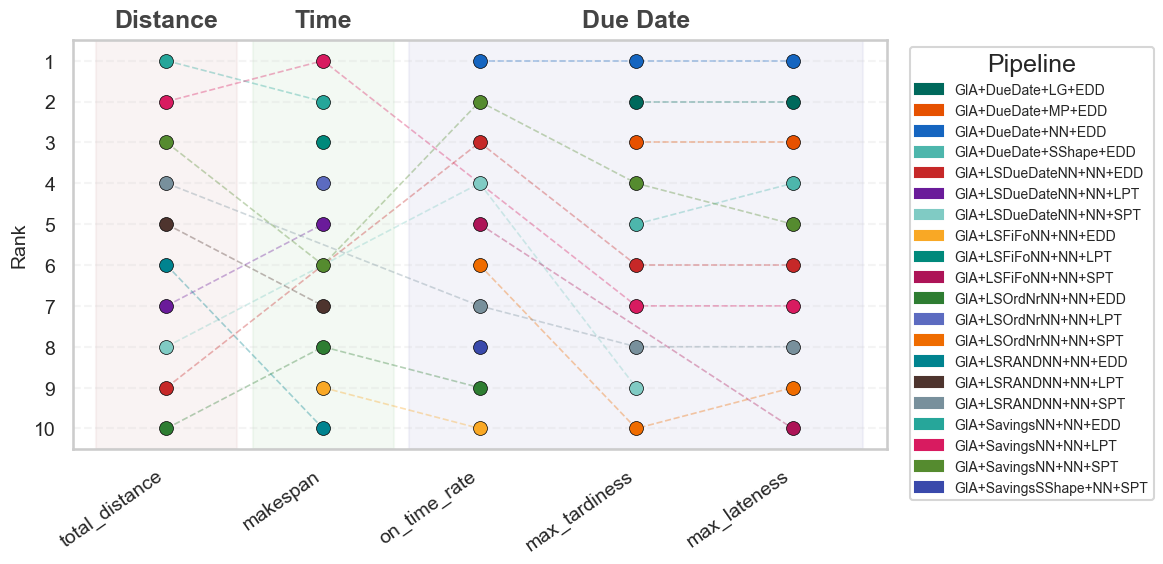

In [123]:
import matplotlib.patches as mpatches

sns.set_style("whitegrid", {'axes.grid' : False})
sns.set_context("talk", rc={"axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14})

def compute_pipeline_ranks(objectives_config, pipeline_col="strategy"):
    rank_records = []
    for obj_name, cfg in objectives_config.items():
        col = cfg["col"]
        ascending = cfg["ascending"]
        df_obj = cfg["df"].copy()
        df_obj[col] = pd.to_numeric(df_obj[col], errors="coerce")
        df_obj = df_obj.dropna(subset=[col])
        if df_obj.empty:
            continue
        avg_perf = df_obj.groupby(pipeline_col)[col].mean().reset_index()
        avg_perf = avg_perf.sort_values(col, ascending=ascending).reset_index(drop=True)
        avg_perf["rank"] = range(1, len(avg_perf) + 1)
        for _, row in avg_perf.iterrows():
            rank_records.append({
                "pipeline": row[pipeline_col],
                "objective": obj_name,
                "rank": row["rank"],
            })
    return pd.DataFrame(rank_records)


def plot_rank_consistency(df_ranks, title="Pipeline Rankings are not Consistent — IOPVRP",
                          objective_groups=None, top_k=8, figsize=(12, 6)):
    objectives = list(dict.fromkeys(df_ranks["objective"]))

    # Only keep rows where rank <= top_k
    df_plot = df_ranks[df_ranks["rank"] <= top_k].copy()

    pipelines = sorted(df_plot["pipeline"].unique())
    n = len(pipelines)

    # cmap = plt.cm.tab20 if n > 10 else plt.cm.tab10
    # color_map = {p: cmap(i % 20) for i, p in enumerate(pipelines)}
    # rank_palette = [
    # "#00695C", "#00897B", "#26A69A", "#4DB6AC", "#80CBC4",
    # "#B2DFDB", "#E0F2F1", "#004D40", "#00796B", "#009688",
    # "#4CAF50", "#81C784", "#A5D6A7", "#C8E6C9", "#E8F5E9",
    # "#1B5E20", "#2E7D32", "#388E3C", "#43A047", "#66BB6A",
    # ]
    rank_palette = [
    "#00695C",  # dark teal
    "#E65100",  # deep orange
    "#1565C0",  # blue
    "#4DB6AC",  # medium teal
    "#C62828",  # red
    "#6A1B9A",  # purple
    "#80CBC4",  # light teal
    "#F9A825",  # amber
    "#00897B",  # teal
    "#AD1457",  # pink
    "#2E7D32",  # green
    "#5C6BC0",  # indigo
    "#EF6C00",  # orange
    "#00838F",  # cyan
    "#4E342E",  # brown
    "#78909C",  # blue-grey
    "#26A69A",  # teal accent
    "#D81B60",  # magenta
    "#558B2F",  # light green
    "#3949AB",  # dark indigo
    ]
    color_map = {p: rank_palette[i % len(rank_palette)] for i, p in enumerate(pipelines)}
    fig, ax = plt.subplots(figsize=figsize)

    # Background shading
    if objective_groups:
        group_colors = ["#e8d0d0", "#d0e8d0", "#d0d0e8"]
        for gi, (group_name, group_objs) in enumerate(objective_groups.items()):
            indices = [objectives.index(o) for o in group_objs if o in objectives]
            if indices:
                x0 = min(indices) - 0.45
                x1 = max(indices) + 0.45
                c = group_colors[gi % len(group_colors)]
                ax.axvspan(x0, x1, alpha=0.25, color=c, zorder=0)
                ax.text((x0 + x1) / 2, 0.3, group_name, ha="center", va="bottom", fontweight="bold", color="#444")

    # Dots
    for _, row in df_plot.iterrows():
        x = objectives.index(row["objective"])
        ax.scatter(x, row["rank"], color=color_map[row["pipeline"]],
                   s=100, zorder=3, edgecolors="black", linewidths=0.5)

    # Connecting lines — only between objectives where pipeline is top-k
    for pipeline in pipelines:
        df_p = df_plot[df_plot["pipeline"] == pipeline].copy()
        if len(df_p) < 2:
            continue
        xs = [objectives.index(r["objective"]) for _, r in df_p.iterrows()]
        ys = df_p["rank"].values
        order = np.argsort(xs)
        ax.plot(np.array(xs)[order], np.array(ys)[order],
        color=color_map[pipeline], alpha=0.35, linewidth=1.2, zorder=2, linestyle='--')

    ax.set_xticks(range(len(objectives)))
    ax.set_xticklabels(objectives, rotation=35, ha="right")
    ax.set_ylabel("Rank")
    ax.set_yticks(range(1, top_k + 1))
    ax.set_ylim(top_k + 0.5, 0.5)
    ax.set_xlim(-0.6, len(objectives) - 0.4)
    # ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.2, linestyle="--")

    handles = [mpatches.Patch(color=color_map[p], label=p) for p in pipelines]
    # ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=6, title="Strategy")
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", title="Pipeline", fontsize=10)
    plt.tight_layout()
    return fig, ax


objectives_config = {
    "total_distance": {"col": "total_distance", "df": df_kris_due_date, "ascending": True},
    "makespan":       {"col": "makespan",       "df": df_kris_due_date, "ascending": True},
    "on_time_rate":   {"col": "on_time_rate",   "df": df_kris_due_date, "ascending": False},
    # "avg_tardiness":  {"col": "avg_tardiness",  "df": df_kris_due_date, "ascending": True},
    "max_tardiness":  {"col": "max_tardiness",  "df": df_kris_due_date, "ascending": True},
    # "avg_lateness":   {"col": "avg_lateness",   "df": df_kris_due_date, "ascending": True},
    "max_lateness":   {"col": "max_lateness",   "df": df_kris_due_date, "ascending": True},
}

objective_groups = {
    "Distance": ["total_distance"],
    "Time": ["makespan"],
    "Due Date": ["on_time_rate", "max_tardiness", "max_lateness"],
}

df_ranks = compute_pipeline_ranks(objectives_config)

fig, ax = plot_rank_consistency(
    df_ranks,
    objective_groups=objective_groups,
    top_k=10,
)
plt.savefig("plots/kris_strategy_ranks.pdf", bbox_inches="tight", dpi=300)
plt.show()

# VBS vs. Best From Literature

In [124]:
df_sprp_vbs = (
    df_sprp
    .sort_values(['total_distance', 'total_cpu_time'])
    .groupby('instance_name')
    .first()
    .reset_index()
    [['instance_name', 'strategy', 'total_distance', 'total_cpu_time', 'best_literature', 'gap_[%]']]
)

In [125]:
df_sprp_ss_vbs = (
    df_sprp_ss
    .sort_values(['total_distance', 'total_cpu_time'])
    .groupby('instance_name')
    .first()
    .reset_index()
    [['instance_name', 'strategy', 'total_distance', 'total_cpu_time', 'best_literature', 'gap_[%]']]
)

In [126]:
df_foodmart_vbs = df_foodmart.loc[df_foodmart.groupby("instance_name")["total_distance"].idxmin(), ["instance_name", "strategy", "total_distance", "total_cpu_time", "gap_[%]", "Number of orders", "num_batches", "best_literature"]]

In [127]:
df_henn_vbs = (
    df_henn
    .sort_values(['total_distance', 'total_cpu_time'])
    .groupby('instance_name')
    .first()
    .reset_index()
    [['instance_name', 'strategy', 'total_distance', 'total_cpu_time', 'gap_[%]', 'number of orders', 'capacity', 'num_batches', 'best_literature']]
)

In [128]:
df_henn_vbs

,instance_name,strategy,total_distance,total_cpu_time,gap_[%],number of orders,capacity,num_batches,best_literature
0,10l-40-45-4_cb,GIA+SavingsRR+RR,5058.0,1.029683,6.786134,40.0,45.0,14.0,4736.57
1,10l-40-45-5_cb,GIA+SavingsRR+RR,4322.0,1.083234,6.047297,40.0,45.0,13.0,4075.54
2,10l-40-45-8_cb,GIA+SavingsRR+RR,5446.0,0.977742,4.076886,40.0,45.0,15.0,5232.67
3,10l-40-45-9_cb,GIA+SavingsRR+RR,4181.0,1.095400,2.384147,40.0,45.0,12.0,4083.64
4,11l-40-60-4_cb,GIA+SavingsNN+RR,4216.0,0.202331,9.235533,40.0,60.0,11.0,3859.55
...,...,...,...,...,...,...,...,...,...
416,9l-40-30-7_u,GIA+SavingsRR+RR,8136.0,0.755936,3.445645,40.0,30.0,19.0,7865.00
417,9l-40-30-8_cb,GIA+SavingsRR+RR,7244.0,0.529532,0.793099,40.0,30.0,22.0,7187.00
418,9l-40-30-8_u,GIA+SavingsRR+RR,9463.0,0.600094,0.734511,40.0,30.0,22.0,9394.00
419,9l-40-30-9_cb,GIA+SavingsRR+RR,6261.0,0.592689,2.203722,40.0,30.0,20.0,6126.00


In [129]:
df_henn_cb_vbs = (
    df_henn_cb
    .sort_values(['total_distance', 'total_cpu_time'])
    .groupby('instance_name')
    .first()
    .reset_index()
    [['instance_name', 'strategy', 'total_distance', 'total_cpu_time', 'gap_[%]', 'number of orders', 'capacity', 'num_batches']]
)

In [130]:
df_henn_uf_vbs = (
    df_henn
    .sort_values(['total_distance', 'total_cpu_time'])
    .groupby('instance_name')
    .first()
    .reset_index()
    [['instance_name', 'strategy', 'total_distance', 'total_cpu_time', 'gap_[%]', 'number of orders', 'capacity', 'num_batches']]
)

In [131]:
df_muter_oencan_vbs = (
    df_muter_oencan
    .sort_values(['total_distance', 'total_cpu_time'])
    .groupby('instance_name')
    .first()
    .reset_index()
    [['instance_name', 'strategy', 'total_distance', 'total_cpu_time', 'gap_[%]', 'number of orders', 'capacity', 'num_batches', 'best_literature']]
)

In [132]:
df_muter_oencan_vbs

,instance_name,strategy,total_distance,total_cpu_time,gap_[%],number of orders,capacity,num_batches,best_literature
0,20_24_0,GIA+LSBatchingRR+RR,661.6,0.589197,1.941448,20.0,24.0,6.0,649.00
1,20_24_1,GIA+SavingsRR+RR,674.8,0.286428,3.022901,20.0,24.0,6.0,655.00
2,20_24_2,GIA+SavingsRR+RR,676.4,0.308886,0.356083,20.0,24.0,6.0,674.00
3,20_24_3,GIA+SavingsRR+RR,608.0,0.325896,4.827586,20.0,24.0,6.0,580.00
4,20_24_4,GIA+LSBatchingRR+RR,618.0,0.407728,8.611599,20.0,24.0,6.0,569.00
5,20_24_5,GIA+SavingsNN+RR,524.8,0.021421,0.344168,20.0,24.0,5.0,523.00
6,20_24_6,GIA+SavingsRR+RR,570.4,0.334999,3.333333,20.0,24.0,5.0,552.00
7,20_24_7,GIA+LSBatchingRR+RR,580.8,0.769499,3.714286,20.0,24.0,6.0,560.00
8,20_24_8,GIA+LSBatchingRR+RR,741.2,0.478805,9.000000,20.0,24.0,8.0,680.00
9,20_24_9,GIA+SavingsRR+RR,506.8,0.329725,1.157685,20.0,24.0,5.0,501.00


In [133]:
df_bahceci_oencan_vbs = (
    df_bahceci_oencan.loc)[df_bahceci_oencan.groupby("instance_name")["total_distance"].idxmin(), ["instance_name", "strategy", "total_distance", "total_cpu_time", "gap_[%]", "number of orders", "capacity", "num_batches", "best_literature"]]

In [134]:
df_kris_vbs = (
    df_kris_distance.loc)[df_kris_distance.groupby("instance_name")["total_distance"].idxmin(), ["instance_name", "strategy", "total_distance", "total_cpu_time", "gap_[%]", "num_batches", "best_total_distance", "instance_set"]]

df_kris_vbs.rename(columns={"best_total_distance": "best_literature"}, inplace=True)

In [135]:
df_kris_vbs.instance_name.nunique()

480

In [136]:
df_bahceci_oencan_vbs

,instance_name,strategy,total_distance,total_cpu_time,gap_[%],number of orders,capacity,num_batches,best_literature
20,Pr_20_1_20_Store1_01,GIA+SEEDCDMaxArticles+RR,127.2,0.001954,-1.117206e-14,8,20,1.0,127.2
15,Pr_20_1_20_Store1_02,GIA+LSBatchingRR+RR,119.2,0.002532,-1.192186e-14,8,20,1.0,119.2
38,Pr_20_1_20_Store1_03,GIA+SEEDCDMinDist+RR,133.2,0.001912,0.000000e+00,8,20,1.0,133.2
51,Pr_20_1_20_Store1_04,GIA+OrdNr+RR,123.2,0.001297,-1.153478e-14,8,20,1.0,123.2
270,Pr_20_1_20_Store1_05,GIA+RAND+RR,121.2,0.001623,-1.172513e-14,8,20,1.0,121.2
...,...,...,...,...,...,...,...,...,...
90147,Pr_30_6_05_Store5_26,GIA+LSBatchingRR+RR,276.4,0.037178,0.000000e+00,12,5,6.0,276.4
90194,Pr_30_6_05_Store5_27,GIA+CombinedBatchingRoutingAssigning,280.4,250.331453,0.000000e+00,12,5,6.0,280.4
90258,Pr_30_6_05_Store5_28,GIA+CombinedBatchingRoutingAssigning,245.6,252.300345,-1.157236e-14,12,5,6.0,245.6
90323,Pr_30_6_05_Store5_29,GIA+CombinedBatchingRoutingAssigning,183.6,250.578259,-1.548023e-14,12,5,6.0,183.6


In [137]:
df_kris_vbs = df_kris_vbs.dropna(subset=["gap_[%]"])

In [169]:
df_kris_tardiness_vbs = df_kris_tardiness_vbs.dropna(subset=["gap_[%]"])

In [170]:
df_kris_makespan_vbs = df_kris_makespan_vbs.dropna(subset=["gap_[%]"])

In [171]:
df_kris_on_time_vbs = df_kris_on_time_vbs.dropna(subset=["gap_[%]"])

In [172]:
df_kris_distance_due_date_vbs = df_kris_distance_due_date_vbs.dropna(subset=["gap_[%]"])
df_kris_distance_due_date_vbs.rename(columns={'best_total_distance': 'best_literature'}, inplace=True)
df_kris_distance_due_date_vbs.drop("on_time_rate", axis=1, inplace=True)

In [173]:
# --- Label instance sets ---
df_muter_oencan_vbs["instance_set"] = "MuterOencan"
df_bahceci_oencan_vbs["instance_set"] = "BahceciOencan"
df_foodmart_vbs["instance_set"] = "Foodmart"
df_henn_vbs["instance_set"] = "HennWaescher"
df_sprp_vbs["instance_set"] = "SPRP"
df_sprp_ss_vbs["instance_set"] = "SPRP-SS"
df_kris_distance_vbs["instance_set"] = "Kris"
df_kris_on_time_vbs["instance_set"] = "Kris"
df_kris_distance_due_date_vbs["instance_set"] = "Kris"

In [143]:
def create_row_vbs(df_vbs: pd.DataFrame, kpi_col="total_distance", objective="distance", best_lit_col="best_literature"):
    row_vbs = pd.DataFrame([{
        "instance_set": df_vbs["instance_set"].unique()[0],
        # "strategy": "VBS", 
        "mean gap": df_vbs["gap_[%]"].mean(), 
        "mean runtime VBS": df_vbs["total_cpu_time"].astype(float).mean(), 
        "mean distance VBS": df_vbs[kpi_col].mean(),
        "best literature": df_vbs[best_lit_col].mean(),
        "n instances": df_vbs["instance_name"].nunique(),
        "objective": objective
    }])
    return row_vbs

def create_pipelines_summary(df_instance: pd.DataFrame):
    pipeline_summary = df_instance.groupby('strategy').agg({
        'gap_[%]': 'mean',
        'total_cpu_time': 'mean',
        'total_distance': 'mean',
        'instance_set': 'count'
    }).reset_index()
    
    pipeline_summary.columns = ['strategy', 'mean gap', 'mean runtime', 'mean distance', 'n instances']
    pipeline_summary.sort_values(by="mean gap", inplace=True)
    
    return pipeline_summary

def create_vbs_tab(df_top_five_gap: pd.DataFrame):
    # Build column alignment: left for first col, right for the rest
    colfmt = "l" + "r" * (df_top_five_gap.shape[1] - 1)
    
    # Generate LaTeX tabular
    latex_tabular = df_top_five_gap.to_latex(
        index=False,
        escape=True,                
        na_rep="--",
        column_format=colfmt,
        float_format="%.2f"
    )
    # Wrap with adjustbox for page fit
    tab = rf"""
    \begin{{table}}[!htbp]
    \centering
    \caption{{Best pipelines of SPRP}}
    \label{{tab:sprp_top_five}}
    \begin{{adjustbox}}{{width=\linewidth,center}}
    {latex_tabular}
    \end{{adjustbox}}
    \end{{table}}
    """
    
    return tab

In [174]:
vbs_tables = [df_sprp_vbs, df_sprp_ss_vbs, df_bahceci_oencan_vbs, df_henn_vbs, df_muter_oencan_vbs, df_foodmart_vbs, df_kris_vbs, df_kris_on_time_vbs, df_kris_distance_due_date_vbs]
vbs_rows = []
for vbs_tab in vbs_tables:
    if vbs_tab["instance_set"].iloc[0] == "Kris" and "on_time_rate" in vbs_tab.columns:
            vbs_row = create_row_vbs(vbs_tab, kpi_col="on_time_rate", objective="ontime", best_lit_col="best_on_time_rate")
            
    else:
        vbs_row = create_row_vbs(vbs_tab)
    # display(vbs_row)
    vbs_rows.append(vbs_row)
tab_vbs_vs_best_lit = pd.concat(vbs_rows)
tab_vbs_vs_best_lit = tab_vbs_vs_best_lit.round(3)
tab_vbs_vs_best_lit['instance_set'] = tab_vbs_vs_best_lit['instance_set'].apply(
    lambda x: rf"\textit{{{x}}}")

tab_vbs_vs_best_lit = tab_vbs_vs_best_lit.rename(columns={
    'instance_set': 'Instance Set',
})

In [175]:
print(tab_vbs_vs_best_lit.to_latex(index=False,
    escape=False,                # escape underscores, % etc.
    na_rep="--",
    column_format=colfmt,
    float_format="%.3f"))

\begin{tabular}{lrrrrrr}
\toprule
Instance Set & mean gap & mean runtime VBS & mean distance VBS & best literature & n instances & objective \\
\midrule
\textit{SPRP} & 0.000 & 0.006 & 589.834 & 589.834 & 2400 & distance \\
\textit{SPRP-SS} & 9.574 & 0.004 & 385.784 & 345.356 & 14300 & distance \\
\textit{BahceciOencan} & 0.015 & 36.333 & 168.102 & 168.074 & 1350 & distance \\
\textit{HennWaescher} & 3.382 & 0.946 & 8686.568 & 8419.793 & 421 & distance \\
\textit{MuterOencan} & 4.807 & 0.610 & 728.222 & 693.375 & 36 & distance \\
\textit{Foodmart} & 6.059 & 0.307 & 850.801 & 801.592 & 42 & distance \\
\textit{Kris} & 6.655 & 0.067 & 69828.082 & 64261.571 & 294 & distance \\
\textit{Kris} & 0.945 & 0.072 & 99.050 & 99.993 & 294 & ontime \\
\textit{Kris} & 13.945 & 0.062 & 81898.231 & 64261.571 & 294 & distance \\
\bottomrule
\end{tabular}



In [146]:
create_row_vbs(df_kris_on_time_vbs, best_lit_col="best_total_distance")

,instance_set,mean gap,mean runtime VBS,mean distance VBS,best literature,n instances,objective
0,Kris,0.944582,0.072157,89011.768707,64261.571429,294,distance


In [147]:
tab_vbs_vs_best_lit

,Instance Set,mean gap,mean runtime VBS,mean distance VBS,best literature,n instances,objective
0,\textit{SPRP},0.000,0.006,589.834,589.834,2400,distance
0,\textit{SPRP-SS},9.574,0.004,385.784,345.356,14300,distance
0,\textit{BahceciOencan},0.015,36.333,168.102,168.074,1350,distance
0,\textit{HennWaescher},3.382,0.946,8686.568,8419.793,421,distance
0,\textit{MuterOencan},4.807,0.610,728.222,693.375,36,distance
0,\textit{Foodmart},6.059,0.307,850.801,801.592,42,distance
0,\textit{Kris},6.655,0.067,69828.082,64261.571,294,distance
0,\textit{Kris},0.945,0.072,99.050,99.993,294,ontime
0,\textit{Kris},42.064,0.072,89011.769,64261.571,294,distance


In [148]:
df_kris_makespan_vbs["instance_set"] = "Kris"

In [149]:
vbs_row_kris_on_time = create_row_vbs(df_kris_on_time_vbs, kpi_col="on_time_rate", objective="ontime", best_lit_col="best_on_time_rate")

In [150]:
df_kris_on_time_vbs

,instance_name,strategy,on_time_rate,best_on_time_rate,total_distance,best_total_distance,total_cpu_time,gap_[%],instance_set
1,instances_100_1_small,GIA+LSFiFoNN+NN+EDD,100.0,100.0,18532.0,16976.0,0.058574,0.0,Kris
3,instances_101_1_small,GIA+LSRANDNN+NN+SPT,100.0,100.0,23488.0,21726.0,0.059414,0.0,Kris
5,instances_102_1_small,GIA+LSFiFoNN+NN+EDD,100.0,100.0,18560.0,17190.0,0.040868,0.0,Kris
7,instances_103_1_small,GIA+LSDueDateNN+NN+SPT,100.0,100.0,23100.0,19680.0,0.010270,0.0,Kris
9,instances_104_1_small,GIA+LSOrdNrNN+MP+SPT,100.0,100.0,32486.0,17574.0,0.018651,0.0,Kris
...,...,...,...,...,...,...,...,...,...
475,instances_98_1_small,GIA+LSDueDateNN+RET+LPT,100.0,100.0,34804.0,14812.0,0.003055,0.0,Kris
476,instances_99_1_large,GIA+DueDate+NN+EDD,97.0,100.0,402746.0,312258.0,0.012413,3.0,Kris
477,instances_99_1_small,GIA+LSFiFoNN+NN+SPT,100.0,100.0,21872.0,17966.0,0.001306,0.0,Kris
478,instances_9_1_large,GIA+DueDate+NN+EDD,100.0,100.0,242686.0,174852.0,0.010545,0.0,Kris


In [151]:
vbs_row_kris_on_time

,instance_set,mean gap,mean runtime VBS,mean distance VBS,best literature,n instances,objective
0,Kris,0.944582,0.072157,99.050265,99.993265,294,ontime


In [152]:
df_kris_tardiness_vbs[df_kris_tardiness_vbs["max_tardiness"]>0]

,instance_name,strategy,max_tardiness,best_max_tardiness,total_cpu_time,gap_[%]
79,instances_136_1_small,GIA+DueDate+NN+EDD,1932.0,0.0,0.000129,inf
85,instances_139_1_small,GIA+DueDate+NN+EDD,3516.0,0.0,0.000075,inf
112,instances_151_1_large,GIA+DueDate+NN+EDD,2814.0,0.0,0.011475,inf
149,instances_168_1_small,GIA+DueDate+NN+EDD,11808.0,0.0,0.000092,inf
150,instances_169_1_large,GIA+DueDate+NN+EDD,9818.0,0.0,0.011828,inf
157,instances_171_1_small,GIA+DueDate+NN+EDD,7296.0,0.0,0.000077,inf
159,instances_172_1_small,GIA+LSDueDateNN+NN+LPT,13386.0,0.0,0.020507,inf
163,instances_174_1_small,GIA+DueDate+NN+EDD,11016.0,0.0,0.000080,inf
167,instances_176_1_small,GIA+DueDate+NN+EDD,18510.0,0.0,0.000569,inf
172,instances_179_1_large,GIA+DueDate+NN+EDD,14512.0,0.0,0.011090,inf


In [153]:
df_kris_on_time_vbs[df_kris_on_time_vbs["on_time_rate"]<100]

,instance_name,strategy,on_time_rate,best_on_time_rate,total_distance,best_total_distance,total_cpu_time,gap_[%],instance_set
79,instances_136_1_small,GIA+DueDate+NN+EDD,94.444444,100.000000,38238.0,33550.0,0.000129,5.555556,Kris
85,instances_139_1_small,GIA+DueDate+NN+EDD,91.666667,100.000000,32410.0,29106.0,0.000075,8.333333,Kris
112,instances_151_1_large,GIA+DueDate+NN+EDD,99.000000,100.000000,322468.0,243724.0,0.011475,1.000000,Kris
149,instances_168_1_small,GIA+LSDueDateNN+NN+EDD,83.333333,100.000000,49272.0,48294.0,0.002311,16.666667,Kris
150,instances_169_1_large,GIA+DueDate+NN+EDD,91.000000,100.000000,697016.0,535686.0,0.011828,9.000000,Kris
157,instances_171_1_small,GIA+LSDueDateNN+NN+EDD,83.333333,100.000000,40076.0,37448.0,0.000498,16.666667,Kris
159,instances_172_1_small,GIA+LSFiFoNN+NN+EDD,88.888889,100.000000,37250.0,36064.0,0.054362,11.111111,Kris
163,instances_174_1_small,GIA+SavingsSShape+NN+SPT,88.888889,100.000000,33454.0,25520.0,0.007988,11.111111,Kris
167,instances_176_1_small,GIA+LSOrdNrNN+NN+EDD,83.333333,100.000000,57316.0,53568.0,0.005215,16.666667,Kris
172,instances_179_1_large,GIA+SavingsNN+NN+SPT,92.000000,100.000000,449726.0,435144.0,0.478643,8.000000,Kris


In [156]:
vbs_row_kris_makespan = create_row_vbs(df_kris_makespan_vbs, kpi_col="makespan", objective="makespan", best_lit_col="best_makespan")

In [157]:
vbs_row_kris_makespan

,instance_set,mean gap,mean runtime VBS,mean distance VBS,best literature,n instances,objective
0,Kris,-22.26471,0.226026,58011.986395,74589.62585,294,makespan


In [158]:
vbs_row_kris_on_time

,instance_set,mean gap,mean runtime VBS,mean distance VBS,best literature,n instances,objective
0,Kris,0.944582,0.072157,99.050265,99.993265,294,ontime


## Plot VBS vs. Optimum

C:\Users\zm0714\AppData\Local\Temp\ipykernel_40396\3129788560.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zm0714\AppData\Local\Temp\ipykernel_40396\3129788560.py:53: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.boxplot(
C:\Users\zm0714\AppData\Local\Temp\ipykernel_40396\3129788560.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\zm0714\AppData\Local\Temp\ipykernel_40396\3129788560.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zm0714\AppData

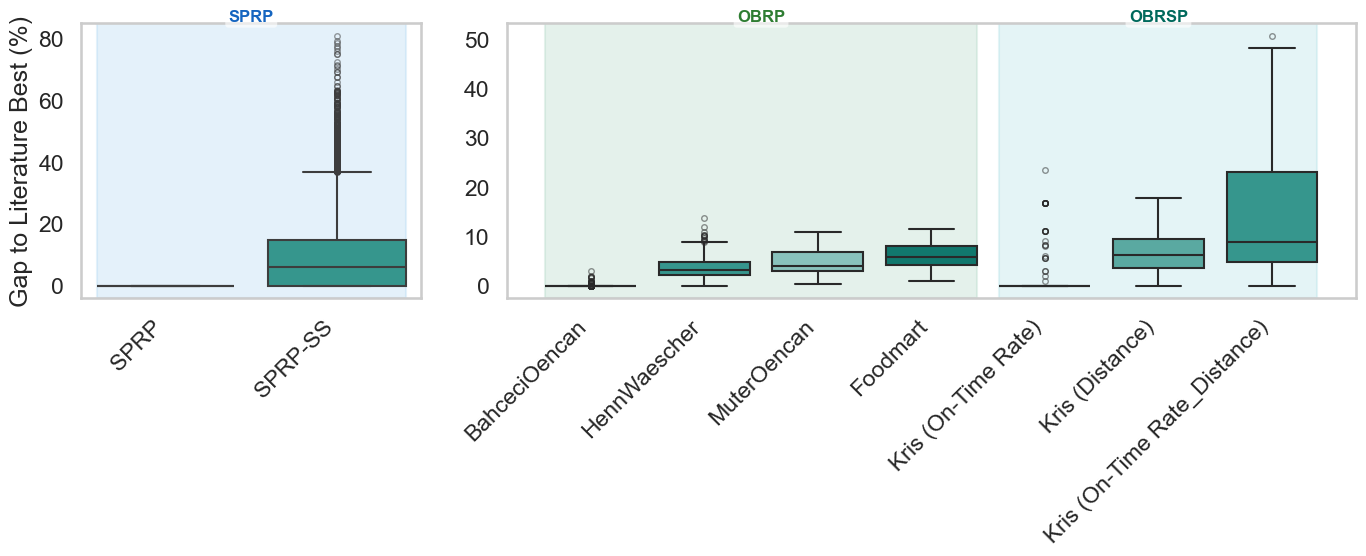

In [184]:
from matplotlib import pyplot as plt
sns.set_style("whitegrid", {'axes.grid' : False})
sns.set_context("talk")

# # --- Label instance sets ---
# df_muter_oencan_vbs["instance_set"] = "MuterOencan"
# df_bahceci_oencan_vbs["instance_set"] = "BahceciOencan"
# df_foodmart_vbs["instance_set"] = "Foodmart"
# df_henn_vbs["instance_set"] = "HennWaescher"
# df_sprp_vbs["instance_set"] = "SPRP"
# df_sprp_ss_vbs["instance_set"] = "SPRP-SS"
df_kris_distance_vbs["instance_set"] = "Kris (Distance)"
df_kris_on_time_vbs["instance_set"] = "Kris (On-Time Rate)"
df_kris_distance_due_date_vbs["instance_set"] = "Kris (On-Time Rate_Distance)"
df_henn_uf_vbs = df_henn_uf_vbs[df_henn_uf_vbs["gap_[%]"] > 0]

all_gaps = pd.concat([
    df_muter_oencan_vbs[['instance_set', 'gap_[%]']],
    df_bahceci_oencan_vbs[['instance_set', 'gap_[%]']],
    df_foodmart_vbs[['instance_set', 'gap_[%]']],
    df_henn_vbs[['instance_set', 'gap_[%]']],
    df_sprp_vbs[['instance_set', 'gap_[%]']],
    df_sprp_ss_vbs[['instance_set', 'gap_[%]']],
    df_kris_distance_vbs[['instance_set', 'gap_[%]']],
    df_kris_on_time_vbs[['instance_set', 'gap_[%]']],
    df_kris_distance_due_date_vbs[['instance_set', 'gap_[%]']]
]).reset_index(drop=True)

all_gaps = all_gaps[all_gaps["gap_[%]"]>=0]
problem_groups = {
    "SPRP": ["SPRP", "SPRP-SS"],
    "OBRP": ["BahceciOencan", "HennWaescher", "HennWaescherUniform", "HennWaescherClassBased", "MuterOencan", "Foodmart"],
    "OBRSP": ["Kris (Distance)", "Kris (On-Time Rate)", "Kris (On-Time Rate_Distance)"]
}

mean_gaps = all_gaps.groupby('instance_set', observed=True)['gap_[%]'].mean()

turquoise_palette = ["#4DB6AC", "#26A69A", "#80CBC4", "#00897B", "#B2DFDB"]
group_bg_colors = {"SPRP": "#B3D9F2", "OBRP": "#B3D9C8", "OBRSP": "#B3E0E6"}
group_label_colors = {"SPRP": "#1565C0", "OBRP": "#2E7D32", "OBRSP": "#00695C"}

def plot_vbs_gap(ax, df, groups_to_plot, show_ylabel="True"):
    """Plot VBS gap boxplots for the given problem groups."""
    # Build sorted instance order
    instance_order = []
    for gname in groups_to_plot:
        present = [i for i in problem_groups[gname] if i in mean_gaps.index]
        instance_order.extend(sorted(present, key=lambda x: mean_gaps[x]))

    subset = df[df['instance_set'].isin(instance_order)].copy()
    subset['instance_set'] = pd.Categorical(subset['instance_set'], categories=instance_order, ordered=True)

    sns.boxplot(
        data=subset, x='instance_set', y='gap_[%]', ax=ax,
        palette=turquoise_palette, order=instance_order,
        linewidth=1.5, flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )

    # Group shading
    for gname in groups_to_plot:
        indices = [instance_order.index(o) for o in problem_groups[gname] if o in instance_order]
        if indices:
            x0, x1 = min(indices) - 0.4, max(indices) + 0.4
            ax.axvspan(x0, x1, alpha=0.35, color=group_bg_colors[gname], zorder=0)
            ax.text((x0 + x1) / 2, 1.05, gname,
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=12, fontweight="bold",
                    color=group_label_colors[gname],
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))
    
    if show_ylabel:
        ax.set_ylabel('Gap to Literature Best (%)')
    else:
        ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('')
    ax.xaxis.label.set_visible(False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 2.5]})

plot_vbs_gap(ax1, all_gaps, ["SPRP"], show_ylabel=True)
plot_vbs_gap(ax2, all_gaps, ["OBRP", "OBRSP"], show_ylabel=False)

# fig.suptitle('VBS Gap to Best Results form Literature', fontsize=14, fontweight='bold')
# fig.text(0.5, -0.02, 'Instance Set', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('./plots/vbs_gap_to_lit_boxplot_combined_v2.png', dpi=200, bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
row_vbs = pd.DataFrame([{
    "strategy": "VBS", 
    "mean gap": df_sprp_ss_vbs["gap_[%]"].mean(), 
    "mean runtime": df_sprp_ss_vbs["total_cpu_time"].astype(float).mean(), 
    "mean distance": df_sprp_ss_vbs["total_distance"].mean(), 
    "n instances": df_sprp_ss_vbs["instance_name"].nunique()
}])

pipeline_summary = df_sprp_ss.groupby('strategy').agg({
    'gap_[%]': 'mean',
    'total_cpu_time': 'mean',
    'total_distance': 'mean',
    'instance_set': 'count'
}).reset_index()

pipeline_summary.columns = ['strategy', 'mean gap', 'mean runtime', 'mean distance', 'n instances']
pipeline_summary.sort_values(by="mean gap", inplace=True)
row_best = pd.DataFrame([{
    "strategy": "best reported", 
    "mean gap": 0, 
    "mean runtime": df_sprp_ss["GS MIP time cplex [ms]"].astype(float).mean() / 1000, 
    "mean distance": df_sprp_ss["LB"].mean(), 
    "n instances": pipeline_summary["n instances"].unique().item()
}])

pipeline_summary = pd.concat([row_best, row_vbs, pipeline_summary], ignore_index=True)
display(pipeline_summary)

In [ ]:
df_top_five_gap = pipeline_summary.round(3)
tab_sprp_ss = create_vbs_tab(df_top_five_gap)

In [ ]:
print(tab_sprp_ss)

In [ ]:
row_vbs = pd.DataFrame([{
    "strategy": "VBS", 
    "mean gap": df_foodmart_vbs["gap_[%]"].mean(), 
    "mean runtime": df_foodmart_vbs["total_cpu_time"].astype(float).mean(), 
    "mean distance": df_foodmart_vbs["total_distance"].mean(), 
    "n instances": df_foodmart_vbs["instance_name"].nunique()
}])

pipeline_summary = df_sprp_ss.groupby('strategy').agg({
    'gap_[%]': 'mean',
    'total_cpu_time': 'mean',
    'total_distance': 'mean',
    'instance_set': 'count'
}).reset_index()

pipeline_summary.columns = ['strategy', 'mean gap', 'mean runtime', 'mean distance', 'n instances']
pipeline_summary.sort_values(by="mean gap", inplace=True)
row_best = pd.DataFrame([{
    "strategy": "best reported", 
    "mean gap": 0, 
    "mean runtime": df_sprp_ss["GS MIP time cplex [ms]"].astype(float).mean() / 1000, 
    "mean distance": df_sprp_ss["LB"].mean(), 
    "n instances": pipeline_summary["n instances"].unique().item()
}])

pipeline_summary = pd.concat([row_best, row_vbs, pipeline_summary], ignore_index=True)
display(pipeline_summary)

## BahceciOencan VBS Table

In [ ]:
row_vbs_bo = create_row_vbs(df_bahceci_oencan_vbs)

pipeline_summary_bo = create_pipelines_summary(df_bahceci_oencan)

pipeline_summary_bo = pd.concat([row_vbs_bo, pipeline_summary_bo], ignore_index=True)
display(row_vbs_bo)

In [ ]:
display(pipeline_summary_bo)

## Foodmart VBS Table

In [ ]:
row_vbs_fm = create_row_vbs(df_foodmart_vbs)

pipeline_summary_fm = create_pipelines_summary(df_foodmart)

pipeline_summary_fm = pd.concat([row_vbs_fm, pipeline_summary_fm], ignore_index=True)
display(pipeline_summary_fm)

In [ ]:
tab_fm = create_vbs_tab(pipeline_summary_fm)

In [ ]:
print(tab_fm)

## Krisdata VBS

In [ ]:
row_vbs_kris = create_row_vbs(df_kris_distance_vbs)

pipeline_summary_kris_dist = create_pipelines_summary(df_kris_distance)

pipeline_summary_kris_dist = pd.concat([row_vbs_kris, pipeline_summary_kris_dist], ignore_index=True)
display(pipeline_summary_kris_dist)

In [ ]:
tab_kris_vbs = create_vbs_tab(pipeline_summary_fm)

In [ ]:
print(tab_kris_vbs)

In [ ]:
df_kris

In [ ]:
# row_vbs = pd.DataFrame([{
#     "strategy": "VBS", 
#     "mean gap": df_sprp_ss_vbs["gap_[%]"].mean(), 
#     "mean runtime": df_sprp_ss_vbs["total_cpu_time"].astype(float).mean(), 
#     "mean distance": df_sprp_ss_vbs["total_distance"].mean(), 
#     "n instances": df_sprp_ss_vbs["instance_name"].nunique()
# }])

pipeline_summary = df_kris.groupby('strategy').agg({
    'gap_[%]': 'mean',
    'total_cpu_time': 'mean',
    'total_distance': 'mean',
    'instance_set': 'count'
}).reset_index()

pipeline_summary.columns = ['strategy', 'mean gap', 'mean runtime', 'mean distance', 'n instances']
pipeline_summary.sort_values(by="mean gap", inplace=True)
# row_best = pd.DataFrame([{
#     "strategy": "best reported", 
#     "mean gap": 0, 
#     "mean runtime": df_sprp_ss["GS MIP time cplex [ms]"].astype(float).mean() / 1000, 
#     "mean distance": df_sprp_ss["LB"].mean(), 
#     "n instances": pipeline_summary["n instances"].unique().item()
# }])

pipeline_summary = pd.concat([row_best, row_vbs, pipeline_summary], ignore_index=True)
display(pipeline_summary)

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

# # --- Label instance sets ---
# df_muter_oencan_vbs["instance_set"] = "MuterOencan"
# df_bahceci_oencan_vbs["instance_set"] = "BahceciOencan"
# df_foodmart_vbs["instance_set"] = "Foodmart"
# df_henn_vbs["instance_set"] = "HennWaescher"
# df_sprp_vbs["instance_set"] = "SPRP"
# df_sprp_ss_vbs["instance_set"] = "SPRP-SS"
# df_kris_distance_vbs["instance_set"] = "Kris"

df_henn_uf_vbs = df_henn_uf_vbs[df_henn_uf_vbs["gap_[%]"] > 0]

all_gaps = pd.concat([
    df_muter_oencan_vbs[['instance_set', 'gap_[%]']],
    df_bahceci_oencan_vbs[['instance_set', 'gap_[%]']],
    df_foodmart_vbs[['instance_set', 'gap_[%]']],
    df_henn_vbs[['instance_set', 'gap_[%]']],
    df_sprp_vbs[['instance_set', 'gap_[%]']],
    df_sprp_ss_vbs[['instance_set', 'gap_[%]']],
    df_kris_distance_vbs[['instance_set', 'gap_[%]']]
]).reset_index(drop=True)

all_gaps = all_gaps[all_gaps["gap_[%]"]>=0]
problem_groups = {
    "SPRP": ["SPRP", "SPRP-SS"],
    "OBRP": ["BahceciOencan", "HennWaescher", "HennWaescherUniform", "HennWaescherClassBased", "MuterOencan", "Foodmart"],
    "OBRSP": ["Kris"]
}

mean_gaps = all_gaps.groupby('instance_set', observed=True)['gap_[%]'].mean()

turquoise_palette = ["#4DB6AC", "#26A69A", "#80CBC4", "#00897B", "#B2DFDB"]
group_bg_colors = {"SPRP": "#B3D9F2", "OBRP": "#B3D9C8", "OBRSP": "#B3E0E6"}
group_label_colors = {"SPRP": "#1565C0", "OBRP": "#2E7D32", "OBRSP": "#00695C"}

def plot_vbs_gap(ax, df, groups_to_plot, show_ylabel="True"):
    """Plot VBS gap boxplots for the given problem groups."""
    # Build sorted instance order
    instance_order = []
    for gname in groups_to_plot:
        present = [i for i in problem_groups[gname] if i in mean_gaps.index]
        instance_order.extend(sorted(present, key=lambda x: mean_gaps[x]))

    subset = df[df['instance_set'].isin(instance_order)].copy()
    subset['instance_set'] = pd.Categorical(subset['instance_set'], categories=instance_order, ordered=True)

    sns.violinplot(
        data=subset, x='instance_set', y='gap_[%]', ax=ax,
        palette=turquoise_palette, order=instance_order,
        linewidth=1.5, inner="box", cut=0
    )

    # Group shading
    for gname in groups_to_plot:
        indices = [instance_order.index(o) for o in problem_groups[gname] if o in instance_order]
        if indices:
            x0, x1 = min(indices) - 0.4, max(indices) + 0.4
            ax.axvspan(x0, x1, alpha=0.35, color=group_bg_colors[gname], zorder=0)
            ax.text((x0 + x1) / 2, 1.05, gname,
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=12, fontweight="bold",
                    color=group_label_colors[gname],
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))
    
    if show_ylabel:
        ax.set_ylabel('Gap to Literature Best (%)')
    else:
        ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('')
    ax.xaxis.label.set_visible(False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 2.5]})

plot_vbs_gap(ax1, all_gaps, ["SPRP"], show_ylabel=True)
plot_vbs_gap(ax2, all_gaps, ["OBRP", "OBRSP"], show_ylabel=False)

# fig.suptitle('VBS Gap to Best Results form Literature', fontsize=14, fontweight='bold')
# fig.text(0.5, -0.02, 'Instance Set', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('./plots/vbs_gap_to_lit_violinplot_combined.png', dpi=200, bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
print(df_sprp_ss_vbs['gap_[%]'].describe())
print(f"% at zero: {(df_sprp_ss_vbs['gap_[%]'] == 0).mean()*100:.1f}%")

## Table VBS vs. SBS vs. Literature

In [ ]:
# SBS Strategy | VBS mean | SBS mean | % improved | # optimal in lit | # solved optimal VBS | mean gap

In [ ]:
df["instance_set"].unique()

In [ ]:
df_vbs_overview = pd.DataFrame()
df_all_winners = []  # collect winners across instance sets

for instance in df["instance_set"].unique():
    df_instance = df[df["instance_set"] == instance]
    # df_instance = df_instance[~df_instance["routing_algo"].isin(["RR", "TSP"])]
    # df_instance = df_instance[~df_instance["batching_algo"].isin(["C&WSShape"])]
    df_instance = df_instance[df_instance["total_distance"]!=0]
    result, winner_counts = vbs_analysis(df_instance)
    result["problem_type"] = df_instance["problem_type"].unique()
    df_winners = winner_counts.reset_index()
    df_winners.columns = ["strategy", "count"]
    df_winners["relative_%"] = df_winners["count"] / df_winners["count"].sum() * 100
    df_winners["instance_set"] = instance  
    # df_winners["problem"] = df_instance["problem_type"]

    df_all_winners.append(df_winners)  # store for later

    df_vbs_overview = pd.concat([df_vbs_overview, result], ignore_index=True)

# Combine all winners into a single dataframe
df_all_winners = pd.concat(df_all_winners, ignore_index=True)

In [ ]:
winners_fm = df_all_winners[df_all_winners["instance_set"]=="FoodmartData"]

In [ ]:
winners_fm

In [ ]:
instance_sets_sorted = ["SPRP", "SPRP-SS", "BahceciOencan", "HennWaescherUniform", "HennWaescherClassBased", "MuterOencan", "FoodmartData", "IOPVRP"]
df_vbs_overview['instance_set'] = pd.Categorical(
    df_vbs_overview['instance_set'], categories=instance_sets_sorted, ordered=True)
df_vbs_overview = df_vbs_overview.sort_values('instance_set')

In [ ]:
df_vbs_overview

In [ ]:
df_vbs_overview_tex = df_vbs_overview.round(2)

# Build column alignment: left for first col, right for the rest
colfmt = "l" + "r" * (df_vbs_overview_tex.shape[1] - 1)

# Generate LaTeX tabular
latex_tabular = df_vbs_overview_tex.to_latex(
    index=False,
    escape=True,                # escape underscores, % etc.
    na_rep="--",
    column_format=colfmt,
    float_format="%.2f"
)

# Wrap with adjustbox for page fit
df_vbs_overview_tex = rf"""
\begin{{table}}[!htbp]
\centering
\caption{{VBS overview}}
\label{{tab:vbs_overview}}
\begin{{adjustbox}}{{width=\linewidth,center}}
{latex_tabular}
\end{{adjustbox}}
\end{{table}}
"""

print(df_vbs_overview_tex)

In [ ]:
df_sprp_ss.item_assignment_algo.unique()